# MSC 2025 Match Prediction: Data Preparation & Model Evaluation


In [1]:
# Install all Python dependencies according to the versions pinned in requirements.txt
# to ensure a reproducible environment (specifically scikit-learn & xgboost versions)
# !pip install -r /content/requirements.txt

# or add only XGBoost dependency
!pip install -q xgboost==3.1.3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 7.5 MB/s eta 0:00:00
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 3.7 MB/s eta 0:00:00

In [2]:
import xgboost
print(xgboost.__version__)

3.1.3


## Init Library

In [3]:
# 1. BASIC UTILITIES — file handling, model serialization (pickle), and iteration progress bars
import os
import json
import math
import itertools
import pickle
from collections import defaultdict
import itertools
from tqdm import tqdm

# 2. DATA & NUMERICS — tabular data structures and numerical operations
import pandas as pd
import numpy as np

# 3. VISUALIZATION — plotting for EDA and model evaluation results (ROC curve, confusion matrix, etc.)
import matplotlib.pyplot as plt
import seaborn as sns

# 4. MACHINE LEARNING
## Model & Preprocessing — two main algorithms compared (RF vs. XGBoost) + feature scaling
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

## Validation & Evaluation — time-aware cross-validation (sequential data matching per patch) + classification metrics
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

# 5. GOOGLE COLAB / DISPLAY CONFIG — so the wide dataset table (42 columns) is fully readable in Colab
from google.colab.data_table import DataTable
DataTable.max_columns = 42

# 6. PANDAS DISPLAY SETTINGS — disable truncation so all columns, rows, and cell contents are fully visible during debugging.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Load Datasets

In [4]:
# Extract the draft pick dataset (hero statistics, ratings, patch notes) and in-game dataset
# (match snapshots taken every minute) to the /content/dataset/ folder.

if not os.path.exists('/content/dataset/draftpick_dataset'):
    !unzip /content/draftpick_dataset.zip -d /content/dataset/
else:
    print('Draft pick dataset already unzipped. Skipping.')

if not os.path.exists('/content/dataset/in-game_dataset'):
    !unzip /content/in-game_dataset.zip -d /content/dataset/
else:
    print('In-game dataset already unzipped. Skipping.')

Draft pick dataset already unzipped. Skipping.
In-game dataset already unzipped. Skipping.


### Draft Pick Dataset

Match statistics data: qualification stage (patch 1.9.68, used as training data)
and MSC 2025 main event (patch 1.9.91, used as test data)

In [5]:
# TRAIN data: draft pick results for the 2025 MSC Qualification round (patch 1.9.68)
qualification_msc25_df = pd.read_csv('/content/dataset/draftpick_dataset/Qualification of MSC 2025 Patch 1.9.68 Global.csv', sep=';', decimal=',')

In [6]:
# TEST Data: MSC 2025 Main Event draft pick results
msc25_df = pd.read_csv('/content/dataset/draftpick_dataset/msc-2025.csv', sep=';', decimal=',')

Hero rating data—categorized by role and damage type—will be used later as input for feature engineering
(not directly for training).

In [7]:
# Ratings per hero per role (offense, durability, etc.); primary source for the "hero rating" feature.
rating_df = pd.read_csv('/content/dataset/draftpick_dataset/hero_rating_detail.csv', sep=';', decimal=',')

In [8]:
# Damage type composition for each hero (physical/magic/mixed), used for the damage type balance feature.
damage_type_mixed_df = pd.read_csv('/content/dataset/draftpick_dataset/damage_type_mixed.csv', sep=';', decimal=',')

Patch note data (hero buffs/nerfs) for patches 1.9.68 (train) and 1.9.91 (test)
are used for the "patch impact" feature during the feature engineering stage.

In [9]:
# Training data patch notes (patch 1.9.68 & minor 1.9.68.1)
with open("/content/dataset/draftpick_dataset/patch_1968.json", "r", encoding="utf-8") as f:
    patch_1968_json = json.load(f)

with open("/content/dataset/draftpick_dataset/patch_19681.json", "r", encoding="utf-8") as f:
    patch_1968_1_json = json.load(f)

# Test data patch notes (Patch 1.9.91 & minor 1.9.91.1)
with open("/content/dataset/draftpick_dataset/patch_1991.json", "r", encoding="utf-8") as f:
    patch_1991_json = json.load(f)

with open("/content/dataset/draftpick_dataset/patch_19911.json", "r", encoding="utf-8") as f:
    patch_1991_1_json = json.load(f)

#### Dataset Overview

##### Dataset information using info()

In [10]:
qualification_msc25_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                553 non-null    int64 
 1   id_date           553 non-null    int64 
 2   no                553 non-null    int64 
 3   match_id          553 non-null    object
 4   game_id           553 non-null    object
 5   tournament        553 non-null    object
 6   stage             553 non-null    object
 7   region            553 non-null    object
 8   date_wib          553 non-null    object
 9   best_of           553 non-null    int64 
 10  game_number       553 non-null    int64 
 11  blue_team         553 non-null    object
 12  red_team          553 non-null    object
 13  blue_explaner     553 non-null    object
 14  blue_jungler      553 non-null    object
 15  blue_midlaner     553 non-null    object
 16  blue_goldlaner    553 non-null    object
 17  blue_roamer     

In [11]:
msc25_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                118 non-null    int64 
 1   no                118 non-null    int64 
 2   match_id          118 non-null    object
 3   game_id           118 non-null    object
 4   tournament        118 non-null    object
 5   stage             118 non-null    object
 6   region            118 non-null    object
 7   date_wib          118 non-null    object
 8   best_of           118 non-null    int64 
 9   game_number       118 non-null    int64 
 10  blue_team         118 non-null    object
 11  red_team          118 non-null    object
 12  blue_explaner     118 non-null    object
 13  blue_jungler      118 non-null    object
 14  blue_midlaner     118 non-null    object
 15  blue_goldlaner    118 non-null    object
 16  blue_roamer       118 non-null    object
 17  red_explaner    

In [12]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    129 non-null    int64  
 1   hero                  129 non-null    object 
 2   main_role             129 non-null    object 
 3   secondary_role        35 non-null     object 
 4   main_lane             129 non-null    object 
 5   secondary_lane        34 non-null     object 
 6   damage_type           129 non-null    object 
 7   first_speciality      129 non-null    object 
 8   secondary_speciality  126 non-null    object 
 9   durability            129 non-null    int64  
 10  offense               129 non-null    int64  
 11  control_effects       129 non-null    int64  
 12  difficulty            129 non-null    int64  
 13  early                 129 non-null    float64
 14  mid                   129 non-null    float64
 15  late                  1

In [13]:
damage_type_mixed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     14 non-null     int64  
 1   hero                   14 non-null     object 
 2   damage_type            14 non-null     object 
 3   physical_damage_ratio  14 non-null     float64
 4   magic_damage_ratio     14 non-null     float64
 5   true_damage_ratio      14 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 804.0+ bytes


##### First few rows of the dataset using head()

In [14]:
qualification_msc25_df.head()

,id,id_date,no,match_id,game_id,tournament,stage,region,date_wib,best_of,game_number,blue_team,red_team,blue_explaner,blue_jungler,blue_midlaner,blue_goldlaner,blue_roamer,red_explaner,red_jungler,red_midlaner,red_goldlaner,red_roamer,blue_bans,red_bans,winner,winner_team,game_duration,patch_version,days_since_patch
0,507,1,1,MPLMYS15W2_0001,MPLMYS15W2_0001-1,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,1,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Wanwan,Jawhead,Cici,Alpha,Selena,Harith,Badang,"Mathilda,Phoveus,Suyou,Cecilion,Yve","Fanny,Kalea,Chip,Moskov,Chou",blue,Team Rey,00.13.05,Patch 1.9.68,2
1,509,3,2,MPLMYS15W2_0001,MPLMYS15W2_0001-2,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,2,Aero Esports,Team Rey,Cici,Joy,Yve,Granger,Kalea,Arlott,Fredrinn,Selena,Natan,Mathilda,"Fanny,Hilda,Harith,Wanwan,Moskov","Chip,Zhuxin,Luo Yi,Cecilion,Pharsa",blue,Aero Esports,00.11.23,Patch 1.9.68,2
2,510,4,3,MPLMYS15W2_0001,MPLMYS15W2_0001-3,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,3,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Harith,Edith,Hylos,Joy,Cecilion,Granger,Badang,"Mathilda,Lukas,Phoveus,Luo Yi,Yve","Fanny,Kalea,Chip,Jawhead,Chou",red,Aero Esports,00.24.14,Patch 1.9.68,2
3,190,7,4,MPLIDS15W5_0001,MPLIDS15W5_0001-1,MPL ID S15,Regular Season,Indonesia,25/04/2025 15.15,3,1,Geek Fam ID,Natus Vincere,Kalea,Fredrinn,Novaria,Granger,Floryn,Phoveus,Joy,Faramis,Clint,Hylos,"Hilda,Lukas,Zhuxin,Mathilda,Bruno","Chip,Luo Yi,Fanny,Arlott,Moskov",blue,Geek Fam ID,00.13.39,Patch 1.9.68,3
4,192,9,5,MPLIDS15W5_0001,MPLIDS15W5_0001-2,MPL ID S15,Regular Season,Indonesia,25/04/2025 15.15,3,2,Geek Fam ID,Natus Vincere,Phoveus,Suyou,Valentina,Granger,Kalea,Hylos,Fredrinn,Novaria,Natan,Chou,"Hilda,Lukas,Zhuxin,Mathilda,Arlott","Chip,Luo Yi,Fanny,Jawhead,Pharsa",blue,Geek Fam ID,00.10.58,Patch 1.9.68,3


In [15]:
msc25_df.head()

,id,no,match_id,game_id,tournament,stage,region,date_wib,best_of,game_number,blue_team,red_team,blue_explaner,blue_jungler,blue_midlaner,blue_goldlaner,blue_roamer,red_explaner,red_jungler,red_midlaner,red_goldlaner,red_roamer,blue_bans,red_bans,winner,winner_team,game_duration,patch_version,days_since_patch
0,1,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8
1,5,2,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-2,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,2,Team Falcons,Rare Atom,Badang,Fredrinn,Pharsa,Granger,Kalea,Esmeralda,Yi Sun-shin,Zetian,Irithel,Hylos,"Lancelot,Wanwan,Arlott,Gatotkaca,Phoveus","Baxia,Uranus,Mathilda,Hayabusa,Joy",red,Rare Atom,00.24.24,Patch 1.9.91.1,8
2,9,3,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-3,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,3,Rare Atom,Team Falcons,Lapu-Lapu,Yi Sun-shin,Kimmy,Moskov,Baxia,Hilda,Uranus,Zhuxin,Granger,Angela,"Pharsa,Kalea,Mathilda,Hayabusa,Joy","Lancelot,Wanwan,Zetian,Esmeralda,Gloo",blue,Rare Atom,00.11.23,Patch 1.9.91.1,8
3,10,4,MSC2025WCA_R01-M002,MSC2025WCA_R01-M002-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 18.00,3,1,Legion Esports,The MongolZ,Uranus,Yi Sun-shin,Novaria,Granger,Gatotkaca,Yu Zhong,Fredrinn,Kimmy,Bruno,Franco,"Phoveus,Zhuxin,Mathilda,Masha,Arlott","Wanwan,Baxia,Kalea,Zetian,Pharsa",red,The MongolZ,00.13.50,Patch 1.9.91.1,8
4,12,5,MSC2025WCA_R01-M002,MSC2025WCA_R01-M002-2,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 18.00,3,2,Legion Esports,The MongolZ,Uranus,Joy,Pharsa,Moskov,Chou,Lapu-Lapu,Fanny,Valentina,Yi Sun-shin,Badang,"Phoveus,Zhuxin,Mathilda,Zetian,Harith","Wanwan,Baxia,Kalea,Angela,Esmeralda",blue,Legion Esports,00.16.39,Patch 1.9.91.1,8


In [16]:
rating_df.head()

,id,hero,main_role,secondary_role,main_lane,secondary_lane,damage_type,first_speciality,secondary_speciality,durability,offense,control_effects,difficulty,early,mid,late
0,1,Miya,Marksman,NaN,Gold Lane,NaN,physical,Finisher,Damage,1,7,4,1,0.20,0.60,0.9
1,2,Balmond,Fighter,NaN,Jungle,Exp Lane,mixed,Damage,Regen,8,3,2,1,0.80,0.90,0.6
2,3,Saber,Assassin,NaN,Jungle,Roam,physical,Charge,Finisher,2,6,6,1,0.85,0.90,0.7
3,4,Alice,Mage,Tank,Exp Lane,Jungle,magic,Charge,Regen,5,5,7,7,0.50,0.72,0.9
4,5,Nana,Mage,NaN,Mid Lane,NaN,magic,Poke,Burst,5,6,10,1,0.40,0.85,0.9


In [17]:
damage_type_mixed_df.head()

,id,hero,damage_type,physical_damage_ratio,magic_damage_ratio,true_damage_ratio
0,2,Balmond,mixed,0.8,0.0,0.2
1,8,Karina,mixed,0.0,0.6,0.4
2,11,Bane,mixed,0.6,0.4,0.0
3,23,Gord,mixed,0.0,0.7,0.3
4,28,Alpha,mixed,0.5,0.0,0.5


##### Overview of patch notes

In [18]:
# Preview the first 3 entries of the patch 1.9.68 note_list to check the JSON structure
print(json.dumps(patch_1968_json["note_list"][:3], indent=2, ensure_ascii=False))

[
  {
    "hero": "Kimmy",
    "type": "Reworked",
    "skills": {
      "Passive": {
        "type": "Reworked",
        "effect_categories": [
          "Damage",
          "Buff"
        ],
        "note": "Mechanic change, ATSPD -> MP",
        "skill_impact": 0.9,
        "patch_impact": 0.9
      },
      "Skill 1": {
        "type": "Reworked",
        "effect_categories": [
          "Speed Up",
          "Buff"
        ],
        "note": "Can pass terrain & immune slow, deal damage to nearby enemies and slow",
        "skill_impact": 0.7,
        "patch_impact": 0.8
      },
      "Skill 2": {
        "type": "Reworked",
        "effect_categories": [
          "CC",
          "Damage",
          "AoE"
        ],
        "note": "Deal Magic Damage in path and immobilizing enemies",
        "skill_impact": 0.6,
        "patch_impact": 0.8
      },
      "Skill 3": {
        "type": "Reworked",
        "effect_categories": [
          "AoE",
          "CC"
        ],
        "no

### In-Game Dataset

In [19]:
# TRAIN data: in-game snapshots (stat per minute) from MSC 2025 Qualification stage
qualification_msc25_df_snapshots = pd.read_csv('/content/dataset/in-game_dataset/Qualification of MSC 2025 Patch 1.9.68 Global_snapshots.csv', sep=';', decimal=',')

In [20]:
# TEST data: in-game snapshots (stat per minute) from MSC 2025 Main Event
msc25_df_snapshots = pd.read_csv('/content/dataset/in-game_dataset/msc-2025_snapshots.csv', sep=';', decimal=',')

#### Dataset Overview (In-Game)

##### Dataset information using info()

In [21]:
qualification_msc25_df_snapshots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 74 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1348 non-null   int64 
 1   id_date                   1348 non-null   int64 
 2   no                        1348 non-null   int64 
 3   game_no                   1348 non-null   int64 
 4   match_id                  1348 non-null   object
 5   game_id                   1348 non-null   object
 6   tournament                1348 non-null   object
 7   stage                     1348 non-null   object
 8   region                    1348 non-null   object
 9   date_wib                  1348 non-null   object
 10  best_of                   1348 non-null   int64 
 11  game_number               1348 non-null   int64 
 12  blue_team                 1348 non-null   object
 13  red_team                  1348 non-null   object
 14  blue_explaner           

In [22]:
msc25_df_snapshots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 72 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        304 non-null    int64 
 1   no                        304 non-null    int64 
 2   match_id                  304 non-null    object
 3   game_id                   304 non-null    object
 4   tournament                304 non-null    object
 5   stage                     304 non-null    object
 6   region                    304 non-null    object
 7   date_wib                  304 non-null    object
 8   best_of                   304 non-null    int64 
 9   game_number               304 non-null    int64 
 10  blue_team                 304 non-null    object
 11  red_team                  304 non-null    object
 12  blue_explaner             304 non-null    object
 13  blue_jungler              304 non-null    object
 14  blue_midlaner             

##### First few rows of the dataset using head()

In [23]:
qualification_msc25_df_snapshots.head()

,id,id_date,no,game_no,match_id,game_id,tournament,stage,region,date_wib,best_of,game_number,blue_team,red_team,blue_explaner,blue_jungler,blue_midlaner,blue_goldlaner,blue_roamer,red_explaner,red_jungler,red_midlaner,red_goldlaner,red_roamer,blue_bans,red_bans,winner,winner_team,game_duration,patch_version,days_since_patch,snapshot_stage,blue_first_blood,red_first_blood,blue_total_gold,red_total_gold,blue_explaner_kda,blue_jungler_kda,blue_midlaner_kda,blue_goldlaner_kda,blue_roamer_kda,red_explaner_kda,red_jungler_kda,red_midlaner_kda,red_goldlaner_kda,red_roamer_kda,blue_explaner_level,blue_jungler_level,blue_midlaner_level,blue_goldlaner_level,blue_roamer_level,red_explaner_level,red_jungler_level,red_midlaner_level,red_goldlaner_level,red_roamer_level,blue_first_turret,red_first_turret,blue_total_turret,red_total_turret,blue_first_inhibitor,red_first_inhibitor,blue_total_inhibitor,red_total_inhibitor,blue_first_turtle,red_first_turtle,blue_total_turtle,red_total_turtle,blue_first_lord,red_first_lord,blue_total_lord,red_total_lord,objective_status_lord,objective_countdown_lord
0,507,1,1,1,MPLMYS15W2_0001,MPLMYS15W2_0001-1,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,1,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Wanwan,Jawhead,Cici,Alpha,Selena,Harith,Badang,"Mathilda,Phoveus,Suyou,Cecilion,Yve","Fanny,Kalea,Chip,Moskov,Chou",blue,Team Rey,00.13.05,Patch 1.9.68,2,9,True,False,27400,23900,0_2_3,1_0_3,1_0_3,2_0_1,1_1_3,0_1_1,1_1_0,1_1_2,1_0_1,0_2_3,9,13,10,12,9,9,11,9,10,8,True,False,4,2,False,False,0,0,True,False,3,0,False,False,0,0,spawned,0
1,508,2,1,1,MPLMYS15W2_0001,MPLMYS15W2_0001-1,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,1,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Wanwan,Jawhead,Cici,Alpha,Selena,Harith,Badang,"Mathilda,Phoveus,Suyou,Cecilion,Yve","Fanny,Kalea,Chip,Moskov,Chou",blue,Team Rey,00.13.05,Patch 1.9.68,2,12,True,False,39200,30700,0_2_7,2_0_7,2_0_7,5_0_3,1_2_6,0_3_2,2_3_1,1_1_3,2_1_1,0_2_4,11,15,12,14,11,11,13,11,12,10,True,False,6,2,True,False,1,0,True,False,3,0,True,False,1,0,waiting,25
2,509,3,2,2,MPLMYS15W2_0001,MPLMYS15W2_0001-2,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,2,Aero Esports,Team Rey,Cici,Joy,Yve,Granger,Kalea,Arlott,Fredrinn,Selena,Natan,Mathilda,"Fanny,Hilda,Harith,Wanwan,Moskov","Chip,Zhuxin,Luo Yi,Cecilion,Pharsa",blue,Aero Esports,00.11.23,Patch 1.9.68,2,9,True,False,30100,21600,0_0_5,8_0_2,1_0_5,2_0_3,0_1_6,0_2_1,0_3_1,0_1_1,0_3_0,1_2_0,10,14,11,11,9,9,10,9,10,8,False,True,5,2,False,False,0,0,True,False,3,0,False,False,0,0,waiting,2
3,510,4,3,3,MPLMYS15W2_0001,MPLMYS15W2_0001-3,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,3,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Harith,Edith,Hylos,Joy,Cecilion,Granger,Badang,"Mathilda,Lukas,Phoveus,Luo Yi,Yve","Fanny,Kalea,Chip,Jawhead,Chou",red,Aero Esports,00.24.14,Patch 1.9.68,2,9,True,False,27500,22600,1_3_2,2_0_3,0_0_6,5_0_2,0_0_7,0_3_3,0_1_3,2_0_1,1_2_1,0_2_3,9,13,10,11,9,8,12,9,10,8,True,False,2,0,False,False,0,0,True,False,3,0,False,False,0,0,spawned,0
4,511,5,3,3,MPLMYS15W2_0001,MPLMYS15W2_0001-3,MPL MY S15,Regular Season,Malaysia,25/04/2025 14.15,3,3,Team Rey,Aero Esports,Hilda,Suyou,Zhuxin,Harith,Edith,Hylos,Joy,Cecilion,Granger,Badang,"Mathilda,Lukas,Phoveus,Luo Yi,Yve","Fanny,Kalea,Chip,Jawhead,Chou",red,Aero Esports,00.24.14,Patch 1.9.68,2,12,True,False,35300,33600,1_4_2,2_1_5,0_0_8,7_1_2,0_0_9,0_3_6,1_2_4,2_1_2,3_2_1,0_2_6,10,15,12,14,10,10,14,11,12,10,True,False,3,1,False,False,0,0,True,False,3,0,False,True,0,1,taken,-2


In [24]:
msc25_df_snapshots.head()

,id,no,match_id,game_id,tournament,stage,region,date_wib,best_of,game_number,blue_team,red_team,blue_explaner,blue_jungler,blue_midlaner,blue_goldlaner,blue_roamer,red_explaner,red_jungler,red_midlaner,red_goldlaner,red_roamer,blue_bans,red_bans,winner,winner_team,game_duration,patch_version,days_since_patch,snapshot_stage,blue_first_blood,red_first_blood,blue_total_gold,red_total_gold,blue_explaner_kda,blue_jungler_kda,blue_midlaner_kda,blue_goldlaner_kda,blue_roamer_kda,red_explaner_kda,red_jungler_kda,red_midlaner_kda,red_goldlaner_kda,red_roamer_kda,blue_explaner_level,blue_jungler_level,blue_midlaner_level,blue_goldlaner_level,blue_roamer_level,red_explaner_level,red_jungler_level,red_midlaner_level,red_goldlaner_level,red_roamer_level,blue_first_turret,red_first_turret,blue_total_turret,red_total_turret,blue_first_inhibitor,red_first_inhibitor,blue_total_inhibitor,red_total_inhibitor,blue_first_turtle,red_first_turtle,blue_total_turtle,red_total_turtle,blue_first_lord,red_first_lord,blue_total_lord,red_total_lord,objective_status_lord,objective_countdown_lord
0,1,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8,9,False,True,24300,24200,0_2_1,1_1_1,0_1_1,0_0_1,1_1_0,0_0_3,2_1_3,1_1_3,0_0_3,2_0_3,10,12,9,11,8,10,11,10,11,9,False,True,2,1,False,False,0,0,True,False,2,1,False,False,0,0,waiting,19
1,2,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8,12,False,True,31300,30700,0_2_1,1_1_1,0_1_1,0_0_1,1_1_0,0_0_3,2_1_3,1_1_3,0_0_3,2_0_3,11,14,11,13,10,11,13,12,13,11,False,True,2,1,False,False,0,0,True,False,2,1,False,False,0,0,spawned,0
2,3,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8,15,False,True,38300,40600,0_2_1,1_1_2,1_2_1,0_1_2,1_1_1,0_0_3,2_1_4,1_1_4,2_0_3,2_1_5,13,15,13,15,11,13,15,14,13,13,False,True,2,6,False,True,0,1,True,False,2,1,False,True,0,1,waiting,58
3,4,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8,18,False,True,46100,50400,0_3_2,2_1_2,1_2_2,0_1_3,1_2_2,0_1_5,2_1_6,1_1_6,4_0_3,2_1_7,15,15,15,15,13,15,15,15,15,15,False,True,2,6,False,True,0,3,True,False,2,1,False,True,0,2,waiting,102
4,5,2,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-2,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,2,Team Falcons,Rare Atom,Badang,Fredrinn,Pharsa,Granger,Kalea,Esmeralda,Yi Sun-shin,Zetian,Irithel,Hylos,"Lancelot,Wanwan,Arlott,Gatotkaca,Phoveus","Baxia,Uranus,Mathilda,Hayabusa,Joy",red,Rare Atom,00.24.24,Patch 1.9.91.1,8,9,True,False,26500,24300,0_1_4,1_0_4,2_0_6,2_0_3,4_2_3,0_3_2,0_1_3,0_1_2,3_1_0,0_3_2,10,12,10,11,9,10,12,9,11,8,True,False,2,2,False,False,0,0,True,False,2,1,False,False,0,0,waiting,11


## Dataset Exploration

### Draft Pick Exploration

In [25]:
# Summarize row count, winner distribution, and patch version breakdown
# for the TRAIN set (Qualification stage)
print("=== Qualification Dataset Summary ===")

row_count = qualification_msc25_df.shape[0]
print(f"Total Rows: {row_count}")

print("\nWinner Distribution:")
print(round(qualification_msc25_df['winner'].value_counts(normalize=True), 2))

print("\nPatch Version Count:")
print(qualification_msc25_df['patch_version'].value_counts())

print("=" * 50)

# Same summary for the TEST set (Main Event MSC25)
print("=== MSC25 Dataset Summary ===")

row_count = msc25_df.shape[0]
print(f"Total Rows: {row_count}")

print("\nWinner Distribution:")
print(round(msc25_df['winner'].value_counts(normalize=True), 2))

print("\nPatch Version Count:")
print(msc25_df['patch_version'].value_counts())

print("=" * 50)

# Combined view (train + test) to check overall class balance and patch coverage.
# Note: this combined_df is exploratory only, not used later as the actual training data.
print("=== Combined Dataset Summary ===")

combined_df = pd.concat([msc25_df, qualification_msc25_df], ignore_index=True)

row_count = combined_df.shape[0]
print(f"Total Rows: {row_count}")

print("\nWinner Count:")
print(combined_df['winner'].value_counts())

print("\nWinner Distribution:")
print(round(combined_df['winner'].value_counts(normalize=True), 2))

print("\nPatch Version Count:")
print(combined_df['patch_version'].value_counts())


=== Qualification Dataset Summary ===
Total Rows: 553

Winner Distribution:
winner
red     0.52
blue    0.48
Name: proportion, dtype: float64

Patch Version Count:
patch_version
Patch 1.9.68.1    286
Patch 1.9.68      267
Name: count, dtype: int64
=== MSC25 Dataset Summary ===
Total Rows: 118

Winner Distribution:
winner
red     0.5
blue    0.5
Name: proportion, dtype: float64

Patch Version Count:
patch_version
Patch 1.9.91.1    118
Name: count, dtype: int64
=== Combined Dataset Summary ===
Total Rows: 671

Winner Count:
winner
red     349
blue    322
Name: count, dtype: int64

Winner Distribution:
winner
red     0.52
blue    0.48
Name: proportion, dtype: float64

Patch Version Count:
patch_version
Patch 1.9.68.1    286
Patch 1.9.68      267
Patch 1.9.91.1    118
Name: count, dtype: int64


In [26]:
# Collect unique team names from both blue and red side (Qualification/train set)
blue_teams_qual = set(qualification_msc25_df["blue_team"].dropna().unique())
red_teams_qual  = set(qualification_msc25_df["red_team"].dropna().unique())

# Union both sides so a team isn't counted twice
all_teams_qual = blue_teams_qual.union(red_teams_qual)

print("Total unique teams:", len(all_teams_qual))
print("\nList of teams:")
for team in sorted(all_teams_qual):
    print("-", team)

Total unique teams: 54

List of teams:
- AP.Bren
- Absolute Zero
- Aero Esports
- Alter Ego
- Aurora Gaming
- Bigetron by Vitality
- CFU Gaming
- CyberHero
- DXSoul Esports
- Dewa United Esports
- Duck Rice Esports
- EVOS
- Everlasting Luv
- Evil
- FORZE Esports
- Galaxy Legends
- Geek Fam ID
- HomeBois
- IGNITE Gaming
- Insilio
- JP NINERS
- KINGS Vanguard
- Kingdom Esports
- Monster Vicious
- Natus Vincere
- Nightwind
- OMBRA Esports
- ONIC
- ONIC Philippines
- Ocean Black
- Omega Esports
- PRO Esports
- Passionfruits
- RRQ Hoshi
- RSG Singapore
- SIBE Team
- See You Soon
- Selangor Red Giants OG Esports
- Sovereign SG
- TNC Pro Team
- TODAK
- Team Falcons PH
- Team Flash
- Team Flash KH
- Team Liquid ID
- Team Liquid PH
- Team Max
- Team Rey
- Team Spirit
- Team Vamos
- Twisted Minds PH
- Valhalla
- Verso Time
- Virtus.pro


In [27]:
# Collect unique team names from both blue and red side (Main Event/test set)
blue_teams_main = set(msc25_df["blue_team"].dropna().unique())
red_teams_main  = set(msc25_df["red_team"].dropna().unique())

# Union both sides so a team isn't counted twice
all_teams_main = blue_teams_main.union(red_teams_main)

print("Total unique teams:", len(all_teams_main))
print("\nList of teams:")
for team in sorted(all_teams_main):
    print("-", team)

Total unique teams: 23

List of teams:
- Area 77
- Aurora Türkiye
- CFU Gaming
- Corinthians
- DianFengYaoGuai
- HomeBois
- INFLUENCE RAGE
- Legion Esports
- Mythic SEAL
- Niightmare Esports
- ONIC
- ONIC Philippines
- RRQ Hoshi
- Rare Atom
- Selangor Red Giants OG Esports
- Team Falcons
- Team Flash
- Team Liquid PH
- Team Spirit
- The MongolZ
- Ultra Legends
- Virtus.pro
- ZETA DIVISION


### In-game Exploration

In [28]:
# Compare row counts between Qualification and Main Event snapshot datasets,
# then combine them for the exploration steps below
print("=== Qualification Snapshots ===")
row_count = qualification_msc25_df_snapshots.shape[0]
print(f"Total Rows: {row_count}")

print("\n=== MSC25 Snapshots ===")
row_count = msc25_df_snapshots.shape[0]
print(f"Total Rows: {row_count}")

# Gabungkan dataset
combined_df = pd.concat(
    [qualification_msc25_df_snapshots, msc25_df_snapshots],
    ignore_index=True
)

row_count = combined_df.shape[0]
print(f"\n=== Combined Snapshots ===")
print(f"Total Rows: {row_count}")


=== Qualification Snapshots ===
Total Rows: 1348

=== MSC25 Snapshots ===
Total Rows: 304

=== Combined Snapshots ===
Total Rows: 1652


In [29]:
# Check class balance (winner label) separately for each snapshot dataset
print("Distribution of 'winner' in qualification_msc25_df_snapshots:")
print(qualification_msc25_df_snapshots['winner'].value_counts())
print("\nDistribution of 'winner' in msc25_df_snapshots:")
print(msc25_df_snapshots['winner'].value_counts())

Distribution of 'winner' in qualification_msc25_df_snapshots:
winner
red     701
blue    647
Name: count, dtype: int64

Distribution of 'winner' in msc25_df_snapshots:
winner
red     152
blue    152
Name: count, dtype: int64


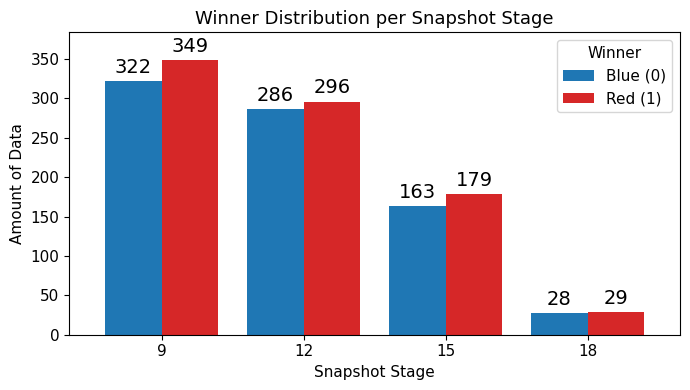

In [30]:
# After (1 cell, reusable plot function called twice for two output sizes)

# Aggregate winner count per snapshot stage (minute mark) across the combined dataset
winner_counts = (
    combined_df.groupby(['snapshot_stage', 'winner'])
    .size()
    .unstack(fill_value=0)
)

def plot_winner_distribution(figsize, bar_width, annot_fontsize, label_fontsize, title_fontsize, ylim_pad):
    """Render the winner-per-snapshot-stage bar chart at a given size.
    Reused for both the full-size (screen) and compact (report) versions."""
    ax = winner_counts.plot(
        kind='bar',
        figsize=figsize,
        width=bar_width,
        color=['#1f77b4', '#d62728']
    )

    # Annotate each bar with its raw count
    for i, stage in enumerate(winner_counts.index):
        for j, winner in enumerate(winner_counts.columns):
            count = winner_counts.loc[stage, winner]
            ax.text(
                i + (j - 0.5) * bar_width * 0.5,
                count + (winner_counts.values.max() * 0.015),
                f"{count}",
                ha='center',
                va='bottom',
                fontsize=annot_fontsize
            )

    plt.ylim(0, winner_counts.values.max() * ylim_pad)
    plt.title("Winner Distribution per Snapshot Stage", fontsize=title_fontsize)
    plt.xlabel("Snapshot Stage", fontsize=label_fontsize)
    plt.ylabel("Amount of Data", fontsize=label_fontsize)
    plt.xticks(rotation=0, fontsize=label_fontsize)
    plt.yticks(fontsize=label_fontsize)
    plt.legend(title="Winner", labels=["Blue (0)", "Red (1)"], fontsize=label_fontsize, title_fontsize=label_fontsize)
    plt.tight_layout()
    plt.show()

# Version 1: full-size chart for on-screen / notebook inspection
plot_winner_distribution(
    figsize=(7, 4), bar_width=0.8,
    annot_fontsize=14, label_fontsize=11, title_fontsize=13, ylim_pad=1.1
)

# Version 2: 3.4-inch compact chart for embedding in report/paper
# plot_winner_distribution(
#     figsize=(3.4, 2.2), bar_width=0.65,
#     annot_fontsize=7, label_fontsize=7, title_fontsize=8, ylim_pad=1.18
# )

# Draft Pick Model Pipeline

## Get statistic from Qualification MSC 2025

In [31]:
# Split the Qualification (train) dataset into separate DataFrames per patch version,
# since each patch has different hero balance and needs to be analyzed independently
patch_dfs = defaultdict(list)
for patch, df in qualification_msc25_df.groupby('patch_version'):
  patch_dfs[patch] = df

print(patch_dfs.keys())

dict_keys(['Patch 1.9.68', 'Patch 1.9.68.1'])


### Initialize Functions

In [32]:
def get_statistic(df_input):
    """
    Compute per-hero, per-role draft pick statistics from a match dataset.

    Pipeline (7 steps):
      1. Build role mapping (lane position -> generic role name)
      2. Aggregate pick/win/ban counts per hero-role
      3. Classify each hero's ban category (meta_ban, comfort_ban, overrated, etc.)
      4. Compute a composite tier score (SS/S/A/B/C/D) per role and overall
      5. Find each hero-role's strongest/weakest matchups (counters)
      6. Compute how often a hero is played in their "main" role vs other roles
      7. Classify hero pair synergy (true_synergy, popular_combo, anti_synergy, etc.)

    Parameters
    ----------
    df_input : pd.DataFrame
        Match-level draft pick data (one row per match, with blue/red hero
        columns per role and a 'winner' column).

    Returns
    -------
    pd.DataFrame
        One row per (hero, role) combination, with all computed statistics
        and classifications merged in.
    """


    ## STEP 1: BASE SETUP
    # Input: df_input (dataframe) and positional_role_map (lane -> role mapping)
    positional_role_map = {
        "blue_explaner": "explaner", "red_explaner": "explaner",
        "blue_jungler": "jungler", "red_jungler": "jungler",
        "blue_midlaner": "midlaner", "red_midlaner": "midlaner",
        "blue_goldlaner": "goldlaner", "red_goldlaner": "goldlaner",
        "blue_roamer": "roamer", "red_roamer": "roamer"
    }

    positional_roles = ["explaner", "jungler", "midlaner", "goldlaner", "roamer"]
    print("✅ STEP 1 complete")

    ## STEP 2: HERO STATS (Pick, Win, Ban)
    hero_lane_stats = defaultdict(lambda: {
        "pick_count": 0,
        "win_count": 0,
    })

    hero_ban_count = defaultdict(int)
    hero_pick_count = defaultdict(int)
    hero_win_count = defaultdict(int)


    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Step 2: Hero pick/win/ban stats"):
        winner = row["winner"]
        for col, lane in positional_role_map.items():
            hero = row[col]
            team = col.split("_")[0]
            key = (hero, lane)

            hero_lane_stats[key]["pick_count"] += 1
            hero_pick_count[hero] += 1
            if winner == team:
                hero_lane_stats[key]["win_count"] += 1
                hero_win_count[hero] += 1

        for side in ["blue_bans", "red_bans"]:
            bans = row[side]
            if isinstance(bans, str):
                for ban in bans.split(","):
                    ban = ban.strip()
                    if ban:
                        hero_ban_count[ban] += 1


    # Convert to DataFrame
    summary = []
    total_matches = len(df_input)
    print(f"Total Matches: {total_matches}")

    for (hero, lane), stats in hero_lane_stats.items():
        pick = stats["pick_count"]
        win = stats["win_count"]

        ban_all = hero_ban_count[hero]
        pick_all = hero_pick_count[hero]
        win_all = hero_win_count[hero]

        ban_rate_all = ban_all / total_matches
        pick_rate = pick / total_matches
        pick_rate_all = pick_all / total_matches
        winrate = win / pick if pick > 0 else None
        winrate_all = win_all / pick_all if pick_all > 0 else None

        summary.append({
            "hero": hero,
            "role": lane,
            "pick_count": pick,
            "pick_count_all": pick_all,
            "pick_rate": pick_rate,
            "pick_rate_all": pick_rate_all,
            "ban_count_all": ban_all,
            "ban_rate_all": ban_rate_all,
            "winrate_if_picked": winrate if winrate is not None else None,
            "winrate_all": winrate_all if winrate_all is not None else None
        })

    # Initial summary data
    print(">> Total Summary Rows:", len(summary))
    df_lane_summary = pd.DataFrame(summary)
    print("✅ STEP 2 complete")

    ## STEP 3: BAN CATEGORY

    def get_dynamic_ban_threshold(df, value=0.75):
        """Compute the ban-count threshold dynamically as a quantile of the dataset,
        instead of using a fixed number, so it adapts to how meta-heavy a patch is."""
        return df["ban_count_all"].quantile(value)


    def assign_ban_category_overall(hero, df, min_picked=10, threshold=200):
        """Classify a hero's ban pattern into: none, skip, meta_ban, comfort_ban,
        overrated, underrated, or situational, based on ban rate, pick rate, and winrate."""
        ban_row = df[df["hero"] == hero]
        if ban_row.empty:
            return "none"

        winrate_all = ban_row["winrate_all"].values[0]
        pick_rate = ban_row["pick_rate_all"].values[0]
        pick_count = ban_row["pick_count_all"].values[0]
        ban_count = ban_row["ban_count_all"].values[0]
        ban_rate = ban_row["ban_rate_all"].values[0]

        if pd.isna(winrate_all):
            return "skip"

        if pick_count < min_picked:
            return "skip"

        if ban_count >= threshold:
            if winrate_all >= 0.53:
                return "meta_ban"
            elif winrate_all < 0.48:
                return "overrated"
            else:
                return "comfort_ban"
        elif ban_rate >= 0.20:
            if pick_rate >= 0.15 and winrate_all >= 0.47:
                return "meta_ban"
            elif pick_rate < 0.10 and winrate_all < 0.45:
                return "overrated"
            else:
                return "comfort_ban"
        elif ban_rate < 0.10:
            if pick_rate < 0.10 and winrate_all >= 0.55:
                return "underrated"
            else:
                return "situational"
        else:
            return "situational"


    # Compute the dynamic threshold first
    ban_count_threshold = get_dynamic_ban_threshold(df_lane_summary)
    print(f"Dynamic Ban Count Threshold: {ban_count_threshold:.0f}")

    # Apply the classification function to every hero
    df_lane_summary['ban_category_overall'] = df_lane_summary["hero"].apply(
        lambda h: assign_ban_category_overall(h, df_lane_summary, threshold=ban_count_threshold)
    )

    # print(f"Dynamic Ban Count Threshold: {ban_count_threshold:.0f}")
    print("✅ STEP 3 complete")

    ## STEP 4: Tier Score

    # Assign tier: SS, S, A, B, C, D
    def assign_tier_by_rank(idx, n):
        """Assign a tier label based on rank percentile within a single role."""
        if idx < n * 0.06:
            return "SS"
        elif idx < n * 0.16:
            return "S"
        elif idx < n * 0.45:
            return "A"
        elif idx < n * 0.65:
            return "B"
        elif idx < n * 0.80:
            return "C"
        else:
            return "D"

    def assign_tier_by_rank_all(idx, n_all):
        """Same as assign_tier_by_rank, but with thresholds tuned for the
        all-role (cross-role) ranking."""
        if idx < n_all * 0.06:
            return "SS"
        elif idx < n_all * 0.15:
            return "S"
        elif idx < n_all * 0.40:
            return "A"
        elif idx < n_all * 0.65:
            return "B"
        elif idx < n_all * 0.85:
            return "C"
        else:
            return "D"

    # Compute the composite score (pick rate + ban rate + winrate, weighted)
    df_lane_summary["score_base"] = (
        df_lane_summary["pick_rate"] * 0.4 +
        df_lane_summary["ban_rate_all"] * 0.3 +
        df_lane_summary["winrate_if_picked"].fillna(0) * 0.4
    )

    # Apply a penalty for heroes with low sample size (few picks)
    max_pick = df_lane_summary["pick_count"].max()
    df_lane_summary["score"] = df_lane_summary["score_base"] * (
        (df_lane_summary["pick_count"] / max_pick) ** 0.5
    )

    # Filter: only heroes with pick_count >= 10
    # df_tiering = df_lane_summary[df_lane_summary["pick_count"] >= 10].copy()
    df_tiering = df_lane_summary.copy()
    df_tiering = df_tiering.sort_values(by="score", ascending=False).reset_index(drop=True)

    df_tiering["tier"] = df_tiering.index.map(lambda idx: assign_tier_by_rank(idx, len(df_tiering)))

    # Merge tier back into df_lane_summary (so the full/unfiltered data still gets exported)
    df_lane_summary = df_lane_summary.drop(columns="tier", errors="ignore")
    df_lane_summary = df_lane_summary.merge(
        df_tiering[["hero", "role", "tier"]], on=["hero", "role"], how="left"
    )

    # All-role tiering (aggregated using pick_count_all instead of per-role pick_count)
    df_all = df_lane_summary.groupby("hero").agg({
        "pick_count_all": "first",
        "ban_rate_all": "first",
        "pick_rate_all": "first",
        "winrate_all": "first",
        "score_base": "mean"
    }).reset_index()

    df_all["score_all"] = (
        df_all["pick_rate_all"] * 0.4 +
        df_all["ban_rate_all"] * 0.4 +
        df_all["winrate_all"].fillna(0) * 0.3
    ) * ((df_all["pick_count_all"] / df_all["pick_count_all"].max()) ** 0.5)

    df_all = df_all.sort_values(by="score_all", ascending=False).reset_index(drop=True)
    df_all["tier_all"] = df_all.index.map(lambda idx: assign_tier_by_rank_all(idx, len(df_all)))

    # Merge tier_all into lane_summary
    df_lane_summary = df_lane_summary.merge(df_all[["hero", "score_all", "tier_all"]], on="hero", how="left")

    print("✅ STEP 4 complete")

    ## STEP 5: STRONG / WEAK AGAINST

    vs_role_stats = defaultdict(lambda: defaultdict(lambda: {"win": 0, "total": 0}))

    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Step 5: Matchup stats (strong/weak against)"):
        blue_win = row["winner"] == "blue"
        red_win = row["winner"] == "red"

        blue_team = {col: (row[col], role) for col, role in positional_role_map.items() if col.startswith("blue")}
        red_team = {col: (row[col], role) for col, role in positional_role_map.items() if col.startswith("red")}

        for b_col, (blue_hero, blue_role) in blue_team.items():
            for r_col, (red_hero, red_role) in red_team.items():
                b_key = (blue_hero, blue_role)
                r_key = (red_hero, red_role)
                vs_role_stats[b_key][r_key]["total"] += 1
                vs_role_stats[r_key][b_key]["total"] += 1
                if blue_win:
                    vs_role_stats[b_key][r_key]["win"] += 1
                if red_win:
                    vs_role_stats[r_key][b_key]["win"] += 1

    # Get top 10 strong/weak matchups based on winrate

    def get_top_counters(matchups, min_match=5, top_k=10, neutral_band=0):
        """
        matchups: dict[(enemy_hero, enemy_role)] -> {"win": int, "total": int}
        neutral_band: margin around 50% considered a "neutral" matchup,
                      so it doesn't get double-listed as both strong and weak.
        """
        # 1) Collect candidates with their winrate and deviation from 50%
        candidates = []
        for enemy_key, val in matchups.items():
            total = val.get("total", 0)
            if total < min_match:
                continue
            wr = val.get("win", 0) / total
            dev = abs(wr - 0.5)
            candidates.append((enemy_key, wr, dev))

        # 2) Keep only the most extreme matchup per enemy hero (largest deviation),
        #    so each enemy hero appears at most once
        best_per_hero = {}
        for (enemy_key, wr, dev) in candidates:
            enemy_hero = enemy_key[0]  # (hero_name, role)
            if enemy_hero not in best_per_hero or dev > best_per_hero[enemy_hero][2]:
                best_per_hero[enemy_hero] = (enemy_key, wr, dev)

        # 3) Classify using the neutral band
        strong, weak = [], []
        for (enemy_key, wr, _dev) in best_per_hero.values():
            if wr >= 0.5 + neutral_band:
                strong.append((enemy_key, wr))
            elif wr <= 0.5 - neutral_band:
                weak.append((enemy_key, wr))
            # else: neutral, skip

        # 4) Sort and (optionally) truncate to top_k
        strong.sort(key=lambda x: x[1], reverse=True)
        weak.sort(key=lambda x: x[1])
        # strong = strong[:top_k]
        # weak = weak[:top_k]

        # 5) Format as "Hero (role)" strings
        fmt = lambda lst: ",".join(f"{ek[0]} ({ek[1]})" for ek, _wr in lst)
        return fmt(strong), fmt(weak)


    # Write strong/weak matchups into the role summary dataframe
    df_lane_summary["strong_against"] = df_lane_summary.apply(
        lambda row: get_top_counters(vs_role_stats.get((row["hero"], row["role"]), {}))[0],
        axis=1
    )

    df_lane_summary["weak_against"] = df_lane_summary.apply(
        lambda row: get_top_counters(vs_role_stats.get((row["hero"], row["role"]), {}))[1],
        axis=1
    )

    print("✅ STEP 5 complete")

    ## STEP 6: ROLE DISTRIBUTION

    role_distribution = defaultdict(lambda: defaultdict(int))

    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Step 6: Role distribution"):
        for col, role in positional_role_map.items():
            hero = row[col]
            role_distribution[hero][role] += 1

    # Compute how often each hero is played in this specific role vs their total appearances
    role_main = []
    for _, row in df_lane_summary.iterrows():
        hero = row['hero']
        role = row['role']
        total = sum(role_distribution[hero].values())
        percent = role_distribution[hero][role] / total if total > 0 else 0
        role_main.append(percent)

    # df_lane_summary["role_main_percent"] = role_main
    df_lane_summary.insert(df_lane_summary.columns.get_loc("role") + 1, "role_main_percent", role_main)

    print("✅ STEP 6 Complete")

    ## STEP 7: SYNERGY CLASSIFICATION

    synergy_stats = defaultdict(lambda: defaultdict(lambda: [0, 0]))
    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Step 7: Synergy classification"):
        blue_team = [(row[f"blue_{r}"], r) for r in positional_roles]
        red_team  = [(row[f"red_{r}"], r) for r in positional_roles]

        for (a_hero, a_role), (b_hero, b_role) in itertools.combinations(blue_team, 2):
            synergy_stats[(a_hero, a_role)][(b_hero, b_role)][1] += 1
            synergy_stats[(b_hero, b_role)][(a_hero, a_role)][1] += 1
            if row["winner"] == "blue":
                synergy_stats[(a_hero, a_role)][(b_hero, b_role)][0] += 1
                synergy_stats[(b_hero, b_role)][(a_hero, a_role)][0] += 1

        for (a_hero, a_role), (b_hero, b_role) in itertools.combinations(red_team, 2):
            synergy_stats[(a_hero, a_role)][(b_hero, b_role)][1] += 1
            synergy_stats[(b_hero, b_role)][(a_hero, a_role)][1] += 1
            if row["winner"] == "red":
                synergy_stats[(a_hero, a_role)][(b_hero, b_role)][0] += 1
                synergy_stats[(b_hero, b_role)][(a_hero, a_role)][0] += 1

    # Classify each hero pair's synergy
    maps = {
        "true_synergy": {}, "popular_combo": {}, "normal_synergy": {}, "anti_synergy": {}
    }

    hero_winrate_lookup = {
        (row['hero'], row['role']): row['winrate_if_picked']
        for _, row in df_lane_summary.iterrows()
    }

    min_synergy_match = max(5, min(10, int(0.05 * len(df_input))))

    for (h1, r1), partners in synergy_stats.items():
        for (h2, r2), (win, total) in partners.items():
            if total >= min_synergy_match: # threshold match
                pair_wr = win / total
                win1 = hero_winrate_lookup.get((h1, r1), 0)
                win2 = hero_winrate_lookup.get((h2, r2), 0)
                avg_wr = (win1 + win2) / 2
                synergy_score = pair_wr - avg_wr
                key = (h1, r1)
                value = f"{h2} ({r2})"
                if synergy_score > 0.05:
                    maps["true_synergy"].setdefault(key, []).append(value)
                elif synergy_score >= -0.02 and pair_wr >= 0.55:
                    maps["popular_combo"].setdefault(key, []).append(value)
                elif synergy_score < -0.05:
                    maps["anti_synergy"].setdefault(key, []).append(value)
                else:
                    maps["normal_synergy"].setdefault(key, []).append(value)

    for label, data in maps.items():
        df_map = pd.DataFrame([{"hero": h, "role": r, label: ",".join(v)} for (h, r), v in data.items()])
        df_lane_summary = df_lane_summary.merge(df_map, on=["hero", "role"], how="left")

    print("\n✅ STEP 7 complete")

    # Return the final per-hero-role statistics dataframe
    return df_lane_summary

### Execute Functions and Save Results

In [33]:
# Combine patch 1.9.68 and its hotfix (1.9.68.1) into one dataset,
# then compute hero/role statistics using get_statistic()
patch_1968 = pd.concat([patch_dfs['Patch 1.9.68'], patch_dfs['Patch 1.9.68.1']])
Patch_1968_stats = get_statistic(patch_1968)

# # Save the statistics dataframe to a CSV file
# Patch_1968_stats.to_csv("/content/statistics/Patch_1968_stats.csv", sep=';', index=False, decimal=',')
# print(f"Successfully saved patch statistics")

✅ STEP 1 complete


Step 2: Hero pick/win/ban stats: 100%|██████████| 553/553 [00:00<00:00, 10594.00it/s]

Total Matches: 553
>> Total Summary Rows: 132
✅ STEP 2 complete
Dynamic Ban Count Threshold: 80
✅ STEP 3 complete


✅ STEP 4 complete


Step 5: Matchup stats (strong/weak against): 100%|██████████| 553/553 [00:00<00:00, 3276.86it/s]


✅ STEP 5 complete


Step 6: Role distribution: 100%|██████████| 553/553 [00:00<00:00, 7487.41it/s]


✅ STEP 6 Complete


Step 7: Synergy classification: 100%|██████████| 553/553 [00:00<00:00, 2190.98it/s]



✅ STEP 7 complete


In [34]:
Patch_1968_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hero                  132 non-null    object 
 1   role                  132 non-null    object 
 2   role_main_percent     132 non-null    float64
 3   pick_count            132 non-null    int64  
 4   pick_count_all        132 non-null    int64  
 5   pick_rate             132 non-null    float64
 6   pick_rate_all         132 non-null    float64
 7   ban_count_all         132 non-null    int64  
 8   ban_rate_all          132 non-null    float64
 9   winrate_if_picked     132 non-null    float64
 10  winrate_all           132 non-null    float64
 11  ban_category_overall  132 non-null    object 
 12  score_base            132 non-null    float64
 13  score                 132 non-null    float64
 14  tier                  132 non-null    object 
 15  score_all             1

In [35]:
Patch_1968_stats.head()

,hero,role,role_main_percent,pick_count,pick_count_all,pick_rate,pick_rate_all,ban_count_all,ban_rate_all,winrate_if_picked,winrate_all,ban_category_overall,score_base,score,tier,score_all,tier_all,strong_against,weak_against,true_synergy,popular_combo,normal_synergy,anti_synergy
0,Hilda,explaner,0.947368,108,114,0.195298,0.206148,116,0.209765,0.472222,0.473684,overrated,0.329938,0.206765,S,0.198609,A,"Selena (midlaner),Gatotkaca (explaner),Ling (jungler),Bruno (goldlaner),Jawhead (roamer),Karrie (goldlaner),Zhuxin (midlaner),Joy (jungler),Cici (explaner),Hylos (explaner),Novaria (midlaner),Beatrix (goldlaner)","Fredrinn (jungler),Chip (roamer),Esmeralda (explaner),Kimmy (midlaner),Granger (goldlaner),Zhask (midlaner),Mathilda (roamer),Chou (roamer),Moskov (goldlaner),Fanny (jungler),Kalea (explaner),Yve (midlaner),Clint (goldlaner),Hayabusa (jungler),Pharsa (midlaner),Gloo (explaner),Badang (explaner),Lukas (jungler),Wanwan (goldlaner),Luo Yi (midlaner),Suyou (jungler),Harith (goldlaner),Valentina (midlaner),Phoveus (explaner)","Suyou (jungler),Moskov (goldlaner),Gatotkaca (roamer),Ling (jungler)",Kalea (roamer),"Zhuxin (midlaner),Hayabusa (jungler),Kimmy (midlaner)","Harith (goldlaner),Granger (goldlaner),Badang (roamer),Joy (jungler),Pharsa (midlaner),Chou (roamer)"
1,Cici,explaner,1.000000,93,93,0.168174,0.168174,87,0.157324,0.440860,0.440860,overrated,0.290811,0.169116,A,0.152628,A,"Valentina (midlaner),Gloo (explaner),Fredrinn (jungler),Chip (roamer),Gatotkaca (roamer),Arlott (explaner),Novaria (midlaner),Hayabusa (jungler),Granger (goldlaner),Hilda (explaner),Selena (midlaner),Baxia (roamer)","Hylos (explaner),Pharsa (midlaner),Yve (midlaner),Luo Yi (midlaner),Chou (roamer),X.Borg (explaner),Wanwan (goldlaner),Moskov (goldlaner),Joy (jungler),Lukas (jungler),Jawhead (roamer),Badang (roamer),Bruno (goldlaner),Phoveus (explaner),Mathilda (roamer),Ling (jungler),Yi Sun-shin (jungler),Harith (goldlaner),Kalea (roamer),Kimmy (midlaner),Zhuxin (midlaner),Suyou (jungler)","Kalea (roamer),Pharsa (midlaner),Suyou (jungler)",NaN,"Harith (goldlaner),Fredrinn (jungler),Gatotkaca (roamer),Hayabusa (jungler)","Granger (goldlaner),Chou (roamer),Valentina (midlaner),Zhuxin (midlaner),Baxia (jungler),Luo Yi (midlaner)"
2,Suyou,jungler,1.000000,189,189,0.341772,0.341772,58,0.104882,0.486772,0.486772,situational,0.362883,0.300837,S,0.269177,S,"Selena (midlaner),Kalea (explaner),Chou (roamer),Valentina (midlaner),Karrie (goldlaner),Gatotkaca (roamer),Hanzo (jungler),Fanny (jungler),Wanwan (goldlaner),Zhuxin (midlaner),Irithel (goldlaner),Edith (explaner),Claude (goldlaner),Hilda (explaner),Cici (explaner),Fredrinn (jungler),Harith (goldlaner),Zhask (midlaner),Gloo (explaner)","Kimmy (midlaner),Beatrix (goldlaner),Alpha (jungler),Yve (midlaner),Badang (roamer),Masha (explaner),Luo Yi (midlaner),Ling (jungler),Leomord (jungler),Bruno (goldlaner),Chip (roamer),Mathilda (roamer),Clint (goldlaner),Esmeralda (explaner),Joy (jungler),Cecilion (midlaner),Phoveus (explaner),Jawhead (roamer),Granger (goldlaner),Hylos (explaner),Pharsa (midlaner),Novaria (midlaner),Moskov (goldlaner),Lukas (jungler),Hayabusa (jungler)","Hilda (explaner),Wanwan (goldlaner),Phoveus (explaner),Selena (midlaner),Hylos (roamer),Zhask (midlaner),Chou (roamer),Cici (explaner),Yve (midlaner),Karrie (goldlaner),Gatotkaca (roamer),Hylos (explaner)",NaN,"Harith (goldlaner),Valentina (midlaner),Kalea (roamer),Moskov (goldlaner),Gatotkaca (explaner),Pharsa (midlaner),Chip (roamer),Kimmy (midlaner)","Zhuxin (midlaner),Jawhead (roamer),Granger (goldlaner),Badang (explaner),Edith (explaner),Gloo (explaner),Faramis (midlaner)"
3,Alpha,jungler,1.000000,20,20,0.036166,0.036166,10,0.018083,0.500000,0.500000,situational,0.219892,0.059300,A,0.046304,B,"Suyou (jungler),Granger (goldlaner),Kimmy (midlaner)",Hayabusa (jungler),Mathilda (roamer),NaN,NaN,NaN
4,Zhuxin,midlaner,0.995261,210,211,0.379747,0.381555,243,0.439421,0.447619,0.445498,overrated,0.462773,0.404400,SS,0.404720,SS,"Gatotkaca

## Separate DataFrames by Statistic and Patch

In [36]:
def generate_df_input(df_role_summary):
    """
    Split the combined per-hero-role statistics dataframe (output of get_statistic())
    into three smaller, purpose-specific DataFrames used later in feature engineering:

      - df_hero_role: hero, role, score, and tier (used for tier/score-based features)
      - df_hero_matchups: hero, role, and strong/weak matchups (used for counter features)
      - df_synergies: hero, role, and synergy classifications (used for synergy features)

    Parameters
    ----------
    df_role_summary : pd.DataFrame
        Output of get_statistic(), one row per (hero, role).

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys: "df_hero_role", "df_hero_matchups", "df_synergies"
    """

    df_hero_role = df_role_summary[[
        "hero", "role", "score", "tier"
    ]]

    df_hero_matchups = df_role_summary[[
        "hero", "role", "strong_against", "weak_against"
    ]]
    df_hero_matchups = df_hero_matchups.merge(
        df_hero_role[["hero", "role"]], on=["hero", "role"]
    )

    df_synergies = df_role_summary[[
        "hero", "role", "true_synergy", "popular_combo", "normal_synergy", "anti_synergy"
    ]]
    df_synergies = df_synergies.merge(
        df_hero_role[["hero", "role"]], on=["hero", "role"]
    )

    return {
        "df_hero_role": df_hero_role.reset_index(drop=True),
        "df_hero_matchups": df_hero_matchups.reset_index(drop=True),
        "df_synergies": df_synergies.reset_index(drop=True)
    }

In [37]:
# Split patch 1.9.68 statistics into the three purpose-specific DataFrames
# (hero_role, hero_matchups, synergies) for use in feature engineering
patch_1968_statistics = generate_df_input(Patch_1968_stats)

## Initialize Feature Engineering

In [38]:
def get_value(df, hero_name, column, default=0):
    """Look up a single column value for a given hero in a DataFrame.
    Returns `default` if the hero isn't found, so callers don't need to
    handle KeyError/IndexError for missing heroes."""
    row = df[df['hero'] == hero_name]
    if not row.empty:
        return row.iloc[0][column]
    return default

In [39]:
def safe_div(x, y):
    """Division that returns 0 instead of raising ZeroDivisionError when y == 0."""
    return x / y if y != 0 else 0

In [40]:
def parse_list(s):
    """Parse a comma-separated 'Hero (role)' string (e.g. from strong_against/
    weak_against/synergy columns) into a plain list of hero names, dropping
    the role suffix. Returns an empty list for NaN or empty input."""
    if pd.isna(s) or s == '':
        return []
    return [x.split(' (')[0].strip() for x in str(s).split(',')]

In [41]:
def get_synergy_score(df_synergies, hero, team_heroes):
    """Compute a weighted synergy score for `hero` against their teammates
    (`team_heroes`), based on synergy classification columns.
    Weights: true_synergy=3, popular_combo=2, normal_synergy=1.5, anti_synergy=-2.
    Higher score = better team fit; negative score = anti-synergy present."""
    row = df_synergies[df_synergies['hero'] == hero]
    if row.empty:
        return 0
    score = 0
    for col, weight in zip(['true_synergy', 'popular_combo', 'normal_synergy', 'anti_synergy'], [3, 2, 1.5, -2]):
        teammates = parse_list(row.iloc[0][col])
        score += sum(weight for t in team_heroes if t in teammates)
    return score

### Feature Engineering Functions

#### Hero Rating

In [42]:
def get_rating_hero_features(df, rating_df, blue_roles, red_roles):
    """
    Build team-level rating features per match by summing each hero's rating
    attributes (offense, durability, control_effects, difficulty) across the
    5 heroes on each side, then deriving ratio-based features from those sums.

    Derived features per side:
      - aggressiveness      = offense / durability
      - damage_efficiency   = offense / difficulty
      - tankiness_efficiency= durability / difficulty
      - control_efficiency  = control_effects / difficulty

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data with blue/red hero columns per role.
    rating_df : pd.DataFrame
        Per-hero rating attributes (offense, durability, control_effects, difficulty).
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role (e.g. 'blue_jungler').

    Returns
    -------
    pd.DataFrame
        One row per match ('no'), with summed attributes and derived ratios
        for both blue and red side.
    """
    base_keys = [
      'offense', 'durability', 'control_effects', 'difficulty'
    ]
    rating_hero_fe = []

    for _, row in df.iterrows():
        blue_vals = {k: 0 for k in base_keys}
        red_vals = {k: 0 for k in base_keys}

        blue_heroes = [row[col] for col in blue_roles]
        red_heroes = [row[col] for col in red_roles]

        # Sum each rating attribute across all 5 heroes per side
        for h in blue_heroes:
            for attr in base_keys:
               blue_vals[attr] += get_value(rating_df, h, attr)

        for h in red_heroes:
            for attr in base_keys:
                red_vals[attr] += get_value(rating_df, h, attr)

        row_data = {'no': row['no']}
        for k in base_keys:
            row_data[f'blue_{k}'] = blue_vals[k]
            row_data[f'red_{k}'] = red_vals[k]

        # Derived ratio features (guarded against division by zero via safe_div)
        row_data['blue_aggressiveness'] = safe_div(blue_vals['offense'], blue_vals['durability'])
        row_data['red_aggressiveness'] = safe_div(red_vals['offense'], red_vals['durability'])

        row_data['blue_damage_efficiency'] = safe_div(blue_vals['offense'], blue_vals['difficulty'])
        row_data['red_damage_efficiency'] = safe_div(red_vals['offense'], red_vals['difficulty'])

        row_data['blue_tankiness_efficiency'] = safe_div(blue_vals['durability'], blue_vals['difficulty'])
        row_data['red_tankiness_efficiency'] = safe_div(red_vals['durability'], red_vals['difficulty'])

        row_data['blue_control_efficiency'] = safe_div(blue_vals['control_effects'], blue_vals['difficulty'])
        row_data['red_control_efficiency'] = safe_div(red_vals['control_effects'], red_vals['difficulty'])

        rating_hero_fe.append(row_data)

    return pd.DataFrame(rating_hero_fe)

#### Damage Type Balance Feature

In [43]:
def get_damage_type_balance_features(df, rating_df, damage_type_mixed_df, blue_roles, red_roles):
    """
    Build team-level damage type composition features per match: how much of
    each team's damage output is physical/magic/true, and how "balanced" that
    mix is (via Shannon entropy).

    For heroes with damage_type == 'mixed', the physical/magic/true split is
    looked up from damage_type_mixed_df instead of counted as a single type.

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data with blue/red hero columns per role.
    rating_df : pd.DataFrame
        Per-hero info including 'damage_type' (physical/magic/true/mixed).
    damage_type_mixed_df : pd.DataFrame
        Physical/magic/true damage ratios for heroes with damage_type == 'mixed'.
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role.

    Returns
    -------
    pd.DataFrame
        One row per match ('no'), with physical/magic/true damage counts and
        a 'damage_balance' (entropy) score for both blue and red side.
        Higher balance = more evenly spread damage types; 0 = single damage type.
    """
    damage_type_balance_fe = []

    for _, row in df.iterrows():
        blue_heroes = [row[col] for col in blue_roles]
        red_heroes = [row[col] for col in red_roles]

        row_data = {'no': row['no']}

        for side, heroes in [('blue', blue_heroes), ('red', red_heroes)]:
            physical, magic, true = 0, 0, 0
            for h in heroes:
                hero_info = rating_df[rating_df['hero'] == h].iloc[0]
                if hero_info['damage_type'] == 'mixed':
                    mix_row = damage_type_mixed_df[damage_type_mixed_df['hero'] == h]
                    if mix_row.empty:
                        raise ValueError(f"Hero '{h}' has damage_type 'mixed' but was not found in damage_type_mixed_df")
                    mix = mix_row.iloc[0]
                    physical += mix['physical_damage_ratio']
                    magic += mix['magic_damage_ratio']
                    true += mix['true_damage_ratio']
                else:
                    if hero_info['damage_type'] == 'physical': physical += 1
                    if hero_info['damage_type'] == 'magic': magic += 1
                    if hero_info['damage_type'] == 'true': true += 1

            total = physical + magic + true
            ratios = [x/total for x in [physical, magic, true] if total > 0]

            # Shannon entropy: higher value = damage types more evenly distributed across the team
            balance = -sum([p * math.log(p) for p in ratios if p > 0])

            row_data[f'{side}_damage_physical'] = physical
            row_data[f'{side}_damage_magic'] = magic
            row_data[f'{side}_damage_true'] = true
            row_data[f'{side}_damage_balance'] = balance

        damage_type_balance_fe.append(row_data)

    return pd.DataFrame(damage_type_balance_fe)

#### Power Spike Feature

In [44]:
def get_power_spike_features(df, rating_df, blue_roles, red_roles):
    """
    Build team-level power spike features per match by summing each hero's
    early/mid/late game power rating across the 5 heroes on each side.

    Derived features per side:
      - power_spike     = weighted sum favoring late-game power (early*1 + mid*2 + late*3)
      - early_mid_ratio = early / mid  (how front-loaded the team's power curve is)
      - mid_late_ratio  = mid / late

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data with blue/red hero columns per role.
    rating_df : pd.DataFrame
        Per-hero rating attributes including 'early', 'mid', 'late' power values.
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role.

    Returns
    -------
    pd.DataFrame
        One row per match ('no'), with summed early/mid/late power and
        derived power spike / ratio features for both blue and red side.
    """

    def get_hero_power(hero, attr):
        """Fetch a single power-curve attribute (early/mid/late) for one hero."""
        row = rating_df[rating_df['hero'] == hero].iloc[0]
        return row[attr]

    base_keys = ['early', 'mid', 'late']
    power_spike_hero_fe = []

    for _, row in df.iterrows():

        blue_vals = {k: 0 for k in base_keys}
        red_vals = {k: 0 for k in base_keys}

        blue_heroes = [row[col] for col in blue_roles]
        red_heroes = [row[col] for col in red_roles]

        for h in blue_heroes:
            for attr in base_keys:
                blue_vals[attr] += get_hero_power(h, attr)

        for h in red_heroes:
            for attr in base_keys:
                red_vals[attr] += get_hero_power(h, attr)

        row_data = {'no': row['no']}
        for k in base_keys:
            row_data[f'blue_{k}'] = blue_vals[k]
            row_data[f'red_{k}'] = red_vals[k]

        # Weighted power spike: later-game power counts more (favors scaling comps)
        row_data['blue_power_spike'] = blue_vals['early'] * 1 + blue_vals['mid'] * 2 + blue_vals['late'] * 3
        row_data['red_power_spike'] = red_vals['early'] * 1 + red_vals['mid'] * 2 + red_vals['late'] * 3

        row_data['blue_early_mid_ratio'] = safe_div(blue_vals['early'], blue_vals['mid'])
        row_data['red_early_mid_ratio'] = safe_div(red_vals['early'], red_vals['mid'])

        row_data['blue_mid_late_ratio'] = safe_div(blue_vals['mid'], blue_vals['late'])
        row_data['red_mid_late_ratio'] = safe_div(red_vals['mid'], red_vals['late'])

        power_spike_hero_fe.append(row_data)

    return pd.DataFrame(power_spike_hero_fe)

#### Synergy, Counter, and Tier Score

In [45]:
def get_synergy_counter_features(df, blue_roles, red_roles, df_synergies, df_hero_role, df_hero_matchups):
    """
    Build team-level draft quality features per match combining three signals:
      - tier_score:    sum of each hero's overall tier score (from get_statistic)
      - synergy_score: weighted synergy between teammates (see get_synergy_score)
      - strong_score:  count of own heroes that counter an enemy hero
      - weak_score:    count of own heroes that are countered by an enemy hero

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data with blue/red hero columns per role.
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role.
    df_synergies, df_hero_role, df_hero_matchups : pd.DataFrame
        Outputs of generate_df_input(), used as lookup tables.

    Returns
    -------
    pd.DataFrame
        One row per match ('no'), with tier/synergy/strong/weak scores
        for both blue and red side.
    """

    base_keys = [
        'tier_score', 'synergy_score', 'strong_score', 'weak_score'
    ]

    synergy_counter_hero_fe = []
    for _, row in df.iterrows():

        blue_vals = {k: 0 for k in base_keys}
        red_vals = {k: 0 for k in base_keys}

        blue_heroes = [row[col] for col in blue_roles]
        red_heroes = [row[col] for col in red_roles]

        for h in blue_heroes:
            blue_vals['tier_score'] += round(get_value(df_hero_role, h, 'score'), 5)
            blue_vals['synergy_score'] += get_synergy_score(df_synergies, h, blue_heroes)

            # Count how many blue heroes counter an opposing (red) hero
            strong_list = parse_list(get_value(df_hero_matchups, h, 'strong_against', ''))
            blue_vals['strong_score'] += sum(1 for enemy in red_heroes if enemy in strong_list)

            # Count how many blue heroes are countered by an opposing (red) hero
            weak_list = parse_list(get_value(df_hero_matchups, h, 'weak_against', ''))
            blue_vals['weak_score'] += sum(1 for enemy in red_heroes if enemy in weak_list)

        for h in red_heroes:
            red_vals['tier_score'] += round(get_value(df_hero_role, h, 'score'), 5)
            red_vals['synergy_score'] += get_synergy_score(df_synergies, h, red_heroes)

            strong_list = parse_list(get_value(df_hero_matchups, h, 'strong_against', ''))
            red_vals['strong_score'] += sum(1 for enemy in blue_heroes if enemy in strong_list)

            weak_list = parse_list(get_value(df_hero_matchups, h, 'weak_against', ''))
            red_vals['weak_score'] += sum(1 for enemy in blue_heroes if enemy in weak_list)


        row_data = {'no': row['no']}
        for k in base_keys:
            row_data[f'blue_{k}'] = blue_vals[k]
            row_data[f'red_{k}'] = red_vals[k]

        synergy_counter_hero_fe.append(row_data)

    return pd.DataFrame(synergy_counter_hero_fe)

#### Patch Impact Feature

In [46]:
# Lookup table: patch version label -> parsed patch notes JSON
patch_json_files = {
    "Patch 1.9.68": patch_1968_json,
    "Patch 1.9.68.1": patch_1968_1_json,
    "Patch 1.9.91": patch_1991_json,
    "Patch 1.9.91.1": patch_1991_1_json,
}

# Groups each patch version into a major release + its minor/hotfix versions,
# so a match on a hotfix patch (e.g. 1.9.68.1) can pull notes from both
# the major patch and the hotfix
list_patch = {
    'patch_1968': {
        "major": "Patch 1.9.68",
        "minor": ["Patch 1.9.68.1"]
    },
    'patch_1991': {
        "major": "Patch 1.9.91",
        "minor": ["Patch 1.9.91.1"]
    },
}

def get_patch_impact_features(df, blue_roles, red_roles):
    """
    Build team-level "patch impact" features per match: how much each hero
    was recently buffed/nerfed/reworked, weighted by how impactful that
    skill change was.

    For each match, the relevant major + minor patch notes are resolved
    based on the match's patch_version, then each hero's patch score is
    computed from their per-skill balance changes.

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data with blue/red hero columns per role and a
        'patch_version' column.
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role.

    Returns
    -------
    pd.DataFrame
        One row per match ('no'), with a summed patch impact score
        for both blue and red side. Positive = recently buffed/reworked
        favorably; negative = recently nerfed.
    """

    # Weight applied to a skill change based on its type
    patch_type_weight = {
        "buff": 1.0,
        "adjust": 0.5,
        "nerf": -1.0,
        "reworked": 0.8,
        "new": 0.6
    }

    def get_patch_score(hero_name, patch_major_json, patch_minor_json=None):
        """Compute one hero's total patch impact score by summing their
        per-skill (patch_impact * type_weight * skill_impact) across both
        the major patch and, if present, the minor/hotfix patch."""

        score = 0
        hero_major, hero_minor = None, None

        # Find this hero's patch notes in the major patch
        if patch_major_json:
            for note in patch_major_json.get("note_list", []):
                if note.get("hero") == hero_name:
                    hero_major = note
                    break

        # Find this hero's patch notes in the minor/hotfix patch
        if patch_minor_json:
            for note in patch_minor_json.get("note_list", []):
                if note.get("hero") == hero_name:
                    hero_minor = note
                    break

        if hero_major or hero_minor:
            # Merge major + minor skill changes per skill name
            skills = {}
            if hero_major:
                for skill, info in hero_major.get("skills", {}).items():
                    skills.setdefault(skill, {})["major"] = info
            if hero_minor:
                for skill, info in hero_minor.get("skills", {}).items():
                    skills.setdefault(skill, {})["minor"] = info

            for skill, info in skills.items():
                skill_impact = 1
                total = 0

                if "major" in info:
                    sd = info["major"]
                    skill_impact = sd.get("skill_impact", 1)
                    total += sd.get("patch_impact", 0) * patch_type_weight.get(sd.get("type", "").lower(), 0)

                if "minor" in info:
                    sd = info["minor"]
                    skill_impact = sd.get("skill_impact", skill_impact)
                    total += sd.get("patch_impact", 0) * patch_type_weight.get(sd.get("type", "").lower(), 0)

                score += skill_impact * total

        return score

    patch_impact_fe = []
    for _, row in df.iterrows():
        patch_version = row["patch_version"]

        # Resolve which major/minor patch JSON applies to this match's patch_version
        major_json, minor_json = None, None
        for val in list_patch.values():
            if patch_version == val["major"] or patch_version in val["minor"]:
                major_json = patch_json_files.get(val["major"])
                if patch_version in val["minor"]:
                    minor_json = patch_json_files.get(patch_version)
                break

        blue_heroes = [row[col] for col in blue_roles]
        red_heroes = [row[col] for col in red_roles]

        blue_patch_score = sum(get_patch_score(h, major_json, minor_json) for h in blue_heroes)
        red_patch_score = sum(get_patch_score(h, major_json, minor_json) for h in red_heroes)

        patch_impact_fe.append({
            "no": row["no"],
            "blue_patch_impact_score": blue_patch_score,
            "red_patch_impact_score": red_patch_score,
        })

    return pd.DataFrame(patch_impact_fe)


## Execute Feature Engineering

In [47]:
def generate_all_features(df, blue_roles, red_roles, rating_df, damage_type_mixed_df, df_hero_role, df_synergies, df_hero_matchups):
    """
    Run all feature engineering functions on a match dataset and merge their
    outputs into a single DataFrame, keyed by match number ('no').

    Parameters
    ----------
    df : pd.DataFrame
        Match-level data to generate features for (train or test set).
    blue_roles, red_roles : list[str]
        Column names for blue/red hero picks per role.
    rating_df : pd.DataFrame
        Per-hero rating attributes.
    damage_type_mixed_df : pd.DataFrame
        Physical/magic/true damage ratios for 'mixed' damage type heroes.
    df_hero_role, df_synergies, df_hero_matchups : pd.DataFrame
        Precomputed hero statistics (tier/score, synergy, matchups), typically
        from patch_1968_statistics — see the note below on why this is shared
        across both train and test calls.

    Returns
    -------
    pd.DataFrame
        One row per match, containing 'no', 'winner', and every feature
        column produced by the 5 feature engineering functions.
    """

    # Copy to avoid mutating the original df
    fe_result = df[['no', 'winner']].copy()

    # List of feature engineering functions to run, paired with their arguments
    fe_funcs = [
        (get_rating_hero_features, (df, rating_df, blue_roles, red_roles)),
        (get_damage_type_balance_features, (df, rating_df, damage_type_mixed_df, blue_roles, red_roles)),
        (get_power_spike_features, (df, rating_df, blue_roles, red_roles)),
        (get_synergy_counter_features, (df, blue_roles, red_roles, df_synergies, df_hero_role, df_hero_matchups)),
        (get_patch_impact_features, (df,  blue_roles, red_roles,)),
    ]

    for func, args in tqdm(fe_funcs, desc="Generating features"):
        fe_result = fe_result.merge(func(*args), on='no')

    return fe_result

In [48]:
# Build the blue/red column name lists once, reused across all feature
# engineering calls (e.g. 'explaner' -> 'blue_explaner', 'red_explaner')
roles = ['explaner', 'jungler', 'midlaner', 'goldlaner', 'roamer']
blue_roles = [f'blue_{r}' for r in roles]
red_roles = [f'red_{r}' for r in roles]

In [49]:
# Generate features for the TRAIN set (Qualification stage, patch 1.9.68),
# using hero statistics (tier/synergy/matchups) computed from this same
# qualification data
fe_1968_result = generate_all_features(
    qualification_msc25_df,
    blue_roles,
    red_roles,
    rating_df,
    damage_type_mixed_df,
    patch_1968_statistics['df_hero_role'],
    patch_1968_statistics['df_synergies'],
    patch_1968_statistics['df_hero_matchups']
)

Generating features: 100%|██████████| 5/5 [00:40<00:00,  8.15s/it]


In [50]:
fe_1968_result.head()

,no,winner,blue_offense,red_offense,blue_durability,red_durability,blue_control_effects,red_control_effects,blue_difficulty,red_difficulty,blue_aggressiveness,red_aggressiveness,blue_damage_efficiency,red_damage_efficiency,blue_tankiness_efficiency,red_tankiness_efficiency,blue_control_efficiency,red_control_efficiency,blue_damage_physical,blue_damage_magic,blue_damage_true,blue_damage_balance,red_damage_physical,red_damage_magic,red_damage_true,red_damage_balance,blue_early,red_early,blue_mid,red_mid,blue_late,red_late,blue_power_spike,red_power_spike,blue_early_mid_ratio,red_early_mid_ratio,blue_mid_late_ratio,red_mid_late_ratio,blue_tier_score,red_tier_score,blue_synergy_score,red_synergy_score,blue_strong_score,red_strong_score,blue_weak_score,red_weak_score,blue_patch_impact_score,red_patch_impact_score
0,1,blue,26,29,27,22,27,26,25,16,0.962963,1.318182,1.040000,1.812500,1.080000,1.375000,1.080000,1.625000,4.0,1.0,0.0,0.500402,2.5,2.0,0.5,0.943348,3.57,3.90,4.00,4.43,3.35,3.40,21.62,22.96,0.892500,0.880361,1.194030,1.302941,1.24753,1.13346,6.0,7.0,14,8,7,11,-0.17,-0.15
1,2,blue,30,28,21,27,18,27,27,22,1.428571,1.037037,1.111111,1.272727,0.777778,1.227273,0.666667,1.227273,3.0,2.0,0.0,0.673012,2.0,3.0,0.0,0.673012,3.15,3.34,4.05,4.08,3.98,3.47,23.19,21.91,0.777778,0.818627,1.017588,1.175793,1.66514,0.59260,35.0,-4.0,13,5,3,11,-0.60,0.82
2,3,red,25,33,30,24,29,20,22,21,0.833333,1.375000,1.136364,1.571429,1.363636,1.142857,1.318182,0.952381,2.2,2.8,0.0,0.685930,2.0,3.0,0.0,0.673012,3.52,3.15,3.95,3.85,3.65,3.70,22.37,21.95,0.891139,0.818182,1.082192,1.040541,1.43269,1.33713,1.0,21.0,7,14,12,8,-0.50,-0.96
3,4,blue,24,29,26,28,26,17,20,27,0.923077,1.035714,1.200000,1.074074,1.300000,1.037037,1.300000,0.629630,3.0,2.0,0.0,0.673012,1.9,3.1,0.0,0.664064,2.60,3.25,3.95,3.77,4.03,3.62,22.59,21.65,0.658228,0.862069,0.980149,1.041436,1.29060,1.20943,10.0,14.0,13,6,3,9,0.71,0.78
4,5,blue,31,27,28,28,26,27,28,22,1.107143,0.964286,1.107143,1.227273,1.000000,1.272727,0.928571,1.227273,3.9,1.1,0.0,0.526908,2.0,3.0,0.0,0.673012,3.22,3.30,4.15,3.75,3.75,3.57,22.77,21.51,0.775904,0.880000,1.106667,1.050420,1.86720,0.73950,35.0,3.0,14,11,7,10,-0.95,1.69


In [51]:
fe_1968_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   no                         553 non-null    int64  
 1   winner                     553 non-null    object 
 2   blue_offense               553 non-null    int64  
 3   red_offense                553 non-null    int64  
 4   blue_durability            553 non-null    int64  
 5   red_durability             553 non-null    int64  
 6   blue_control_effects       553 non-null    int64  
 7   red_control_effects        553 non-null    int64  
 8   blue_difficulty            553 non-null    int64  
 9   red_difficulty             553 non-null    int64  
 10  blue_aggressiveness        553 non-null    float64
 11  red_aggressiveness         553 non-null    float64
 12  blue_damage_efficiency     553 non-null    float64
 13  red_damage_efficiency      553 non-null    float64

In [52]:
# Generate features for the TEST set (Main Event MSC25) reusing the SAME
# hero statistics computed from the Qualification (train) data, so tier/synergy/
# matchup scores stay consistent with what the model was trained on and don't
# leak information from the test set's own patch into the features
fe_msc25_result = generate_all_features(
    msc25_df,
    blue_roles,
    red_roles,
    rating_df,
    damage_type_mixed_df,
    patch_1968_statistics['df_hero_role'],
    patch_1968_statistics['df_synergies'],
    patch_1968_statistics['df_hero_matchups']
)

Generating features: 100%|██████████| 5/5 [00:04<00:00,  1.13it/s]


In [53]:
fe_msc25_result.head()

,no,winner,blue_offense,red_offense,blue_durability,red_durability,blue_control_effects,red_control_effects,blue_difficulty,red_difficulty,blue_aggressiveness,red_aggressiveness,blue_damage_efficiency,red_damage_efficiency,blue_tankiness_efficiency,red_tankiness_efficiency,blue_control_efficiency,red_control_efficiency,blue_damage_physical,blue_damage_magic,blue_damage_true,blue_damage_balance,red_damage_physical,red_damage_magic,red_damage_true,red_damage_balance,blue_early,red_early,blue_mid,red_mid,blue_late,red_late,blue_power_spike,red_power_spike,blue_early_mid_ratio,red_early_mid_ratio,blue_mid_late_ratio,red_mid_late_ratio,blue_tier_score,red_tier_score,blue_synergy_score,red_synergy_score,blue_strong_score,red_strong_score,blue_weak_score,red_weak_score,blue_patch_impact_score,red_patch_impact_score
0,1,red,28,28,26,23,14,26,19,16,1.076923,1.217391,1.473684,1.750000,1.368421,1.437500,0.736842,1.625000,2.0,3.0,0.0,0.673012,2.0,3.0,0.0,0.673012,2.85,3.42,4.23,4.15,3.80,3.42,22.71,21.98,0.673759,0.824096,1.113158,1.213450,0.70239,1.32070,0.0,9.0,10,4,3,8,0.275,-1.13
1,2,red,30,29,23,28,26,22,17,23,1.304348,1.035714,1.764706,1.260870,1.352941,1.217391,1.529412,0.956522,4.0,1.0,0.0,0.500402,2.5,2.5,0.0,0.693147,3.00,2.78,4.15,3.78,3.78,3.80,22.64,21.74,0.722892,0.735450,1.097884,0.994737,1.66022,0.39387,27.0,0.0,10,2,0,7,-1.780,1.62
2,3,blue,32,22,26,29,19,21,28,19,1.230769,0.758621,1.142857,1.157895,0.928571,1.526316,0.678571,1.105263,3.0,2.0,0.0,0.673012,2.0,3.0,0.0,0.673012,2.53,3.05,3.85,3.90,4.00,3.60,22.23,21.65,0.657143,0.782051,0.962500,1.083333,0.76646,1.06630,10.5,-5.0,9,1,0,8,-1.090,-0.47
3,4,red,30,26,29,27,17,26,21,27,1.034483,0.962963,1.428571,0.962963,1.380952,1.000000,0.809524,0.962963,2.0,3.0,0.0,0.673012,4.0,1.0,0.0,0.500402,2.78,3.40,3.95,3.82,4.00,3.58,22.68,21.78,0.703797,0.890052,0.987500,1.067039,0.77835,0.74322,-3.0,7.0,2,8,4,1,0.340,0.08
4,5,blue,27,36,22,27,22,20,27,31,1.227273,1.333333,1.000000,1.161290,0.814815,0.870968,0.814815,0.645161,2.0,3.0,0.0,0.673012,4.0,1.0,0.0,0.500402,2.75,3.68,3.95,4.30,4.07,3.80,22.86,23.68,0.696203,0.855814,0.970516,1.131579,1.17026,0.65296,17.0,3.0,9,7,3,5,0.260,0.48


## Define DataFrame for Modeling

In [54]:
# Final feature set for modeling: keep only the derived/ratio features from
# each feature engineering function (aggressiveness, efficiency ratios, damage
# balance, power spike, tier/synergy/matchup scores, patch impact), and
# deliberately DROP the raw summed attributes they were derived from
# (e.g. raw blue_offense, blue_durability, blue_early/mid/late) to avoid
# feeding the model near-duplicate/collinear information.
rows_to_keep = [
    'no', 'winner',

    # blue
    'blue_aggressiveness',
    'blue_damage_efficiency',
    'blue_tankiness_efficiency',
    'blue_control_efficiency',
    'blue_damage_balance',
    'blue_power_spike',
    'blue_mid_late_ratio',
    'blue_tier_score',
    'blue_synergy_score',
    'blue_strong_score',
    'blue_weak_score',
    'blue_patch_impact_score',

    # red
    'red_aggressiveness',
    'red_damage_efficiency',
    'red_tankiness_efficiency',
    'red_control_efficiency',
    'red_damage_balance',
    'red_power_spike',
    'red_mid_late_ratio',
    'red_tier_score',
    'red_synergy_score',
    'red_strong_score',
    'red_weak_score',
    'red_patch_impact_score',
]

In [55]:
def get_xy(df, target_col='winner', drop_cols=None, label_mapping=None):
    """
    Split a feature DataFrame into X (features) and y (encoded target label).

    Parameters
    ----------
    df : pd.DataFrame
        Feature dataframe containing the target column plus feature columns.
    target_col : str, default 'winner'
        Column to use as the prediction target.
    drop_cols : list[str], optional
        Columns to exclude from X. Defaults to ['no', target_col].
    label_mapping : dict, optional
        Mapping from raw label values to encoded integers.
        Defaults to {'blue': 0, 'red': 1}.

    Returns
    -------
    X : pd.DataFrame
        Feature columns only.
    y : pd.Series
        Encoded target labels.
    label_mapping : dict
        The mapping used, returned for reference/inverse-mapping later.
    """

    if drop_cols is None:
        drop_cols = ['no', target_col]

    if label_mapping is None:
        label_mapping = {'blue': 0, 'red': 1}  # default

    X = df.drop(columns=drop_cols)
    y = df[target_col].map(label_mapping)

    return X, y, label_mapping

In [56]:
# Apply the selected feature columns (rows_to_keep) to both train and test sets
df_fe_train = fe_1968_result[rows_to_keep].copy()
df_fe_test = fe_msc25_result[rows_to_keep].copy()

In [57]:
# Encode winner label as blue=0, red=1, then split train/test into X (features) and y (target)
label_mapping = {'blue': 0, 'red': 1}
reverse_mapping = {v: k for k, v in label_mapping.items()}

X_train, y_train, _ = get_xy(df_fe_train, label_mapping=label_mapping)
X_test, y_test, _ = get_xy(df_fe_test, label_mapping=label_mapping)

In [58]:
def get_diff_features(df):
    """
    Collapse each blue_X/red_X feature pair into a single diff_X feature
    (red - blue), so the model sees relative advantage between teams instead
    of two separate absolute values. Halves the feature count and removes
    the blue/red naming symmetry, which also avoids the model learning a
    spurious "blue side vs red side" bias.

    Note: computed as (red - blue), so a positive value means Red has the
    advantage on that feature, not Blue.

    Parameters
    ----------
    df : pd.DataFrame
        Feature dataframe with paired 'blue_*' and 'red_*' columns.

    Returns
    -------
    pd.DataFrame
        One 'diff_*' column per blue/red pair found in the input.
    """
    diff_data = []

    for _, row in df.iterrows():
        row_data = {}

        for col in df.columns:
            if col.startswith("blue_"):
                feat_name = col.replace("blue_", "")
                red_col = f"red_{feat_name}"

                if red_col in df.columns:
                    # red - blue, so positive = advantage Red
                    row_data[f"diff_{feat_name}"] = row[red_col] - row[col]

        diff_data.append(row_data)

    return pd.DataFrame(diff_data)

In [59]:
# Convert train/test features from blue_X/red_X pairs into single diff_X features
X_train = get_diff_features(X_train)
X_test = get_diff_features(X_test)

In [60]:
X_train.columns

Index(['diff_aggressiveness', 'diff_damage_efficiency',
       'diff_tankiness_efficiency', 'diff_control_efficiency',
       'diff_damage_balance', 'diff_power_spike', 'diff_mid_late_ratio',
       'diff_tier_score', 'diff_synergy_score', 'diff_strong_score',
       'diff_weak_score', 'diff_patch_impact_score'],
      dtype='object')

In [61]:
print(len(X_train.keys()))

12


In [62]:
X_train.head()

,diff_aggressiveness,diff_damage_efficiency,diff_tankiness_efficiency,diff_control_efficiency,diff_damage_balance,diff_power_spike,diff_mid_late_ratio,diff_tier_score,diff_synergy_score,diff_strong_score,diff_weak_score,diff_patch_impact_score
0,0.355219,0.772500,0.295000,0.545000,0.442946,1.34,0.108911,-0.11407,1.0,-6.0,4.0,0.02
1,-0.391534,0.161616,0.449495,0.560606,0.000000,-1.28,0.158205,-1.07254,-39.0,-8.0,8.0,1.42
2,0.541667,0.435065,-0.220779,-0.365801,-0.012918,-0.42,-0.041651,-0.09556,20.0,7.0,-4.0,-0.46
3,0.112637,-0.125926,-0.262963,-0.670370,-0.008948,-0.94,0.061288,-0.08117,4.0,-7.0,6.0,0.07
4,-0.142857,0.120130,0.272727,0.298701,0.146104,-1.26,-0.056246,-1.12770,-32.0,-3.0,3.0,2.64


## Train and Test Models

In [63]:
# ===== 1. MODEL DEFINITIONS =====
# Two candidate models with fixed hyperparameters (no tuning/grid search here),
# both constrained to max_depth=4 to reduce overfitting risk given the small
# esports match dataset size
models = {
    "RandomForestClassifier": RandomForestClassifier(
        random_state=28,
        n_estimators=100,
        max_depth=4,
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=28,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        subsample=0.85,
    )
}

In [64]:
# ===== 2. TRAIN & EVALUATE EACH MODEL =====
print("=== Model Evaluation Results ===")
for name, model in models.items():
    model.fit(X_train, y_train)

    # Predict on both train and test to check for overfitting (train vs test accuracy gap)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Predicted probabilities for ROC-AUC (assumes binary classification)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    roc_auc_test = roc_auc_score(y_test, y_prob_test)

    print(50*"=")
    print(f"\nModel ({name}) ➞ MSC 2025 Prediction")
    print("Train Accuracy:", round(acc_train, 3))
    print("Test Accuracy:", round(acc_test, 3))
    print("ROC-AUC (Test):", round(roc_auc_test, 3))

    print("\nClassification Report (Test):")
    print(classification_report(
        y_test,
        y_pred_test,
        target_names=[reverse_mapping[c] for c in sorted(reverse_mapping.keys())],
        digits=2
    ))

    cm = confusion_matrix(y_test, y_pred_test, labels=[1, 0])
    print("Confusion Matrix (Test):\n", cm)

=== Model Evaluation Results ===

Model (RandomForestClassifier) ➞ MSC 2025 Prediction
Train Accuracy: 0.783
Test Accuracy: 0.568
ROC-AUC (Test): 0.562

Classification Report (Test):
              precision    recall  f1-score   support

        blue       0.57      0.54      0.56        59
         red       0.56      0.59      0.58        59

    accuracy                           0.57       118
   macro avg       0.57      0.57      0.57       118
weighted avg       0.57      0.57      0.57       118

Confusion Matrix (Test):
 [[35 24]
 [27 32]]

Model (XGBoost) ➞ MSC 2025 Prediction
Train Accuracy: 0.917
Test Accuracy: 0.551
ROC-AUC (Test): 0.579

Classification Report (Test):
              precision    recall  f1-score   support

        blue       0.55      0.61      0.58        59
         red       0.56      0.49      0.52        59

    accuracy                           0.55       118
   macro avg       0.55      0.55      0.55       118
weighted avg       0.55      0.55     

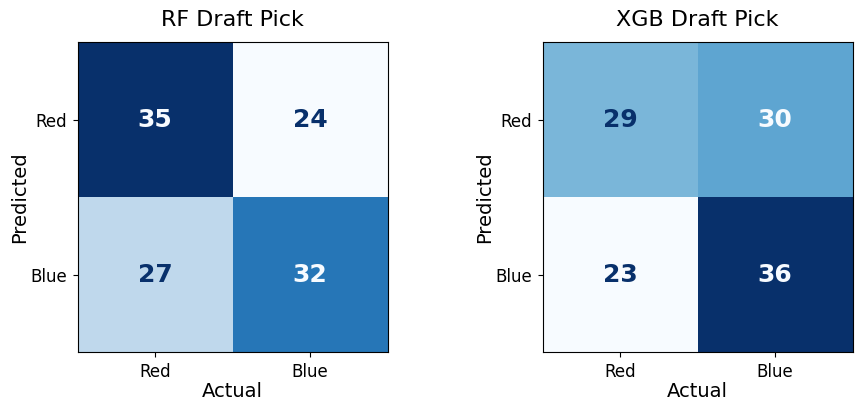

In [65]:
# ===== 3. CONFUSION MATRIX FIGURE (compact, side-by-side RF vs XGB) =====
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
titles = ["RF Draft Pick", "XGB Draft Pick"]

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Red", "Blue"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(titles[list(models.keys()).index(name)], fontsize=16, pad=12)
    ax.set_xlabel("Actual", fontsize=14, labelpad=1)
    ax.set_ylabel("Predicted", fontsize=14, labelpad=1)
    ax.tick_params(labelsize=12, pad=4)

    # Bold the count numbers inside each cell for readability at small size
    for label in ax.texts:
        label.set_fontsize(18)
        label.set_fontweight("bold")

plt.subplots_adjust(wspace=0.5, hspace=0)
plt.show()

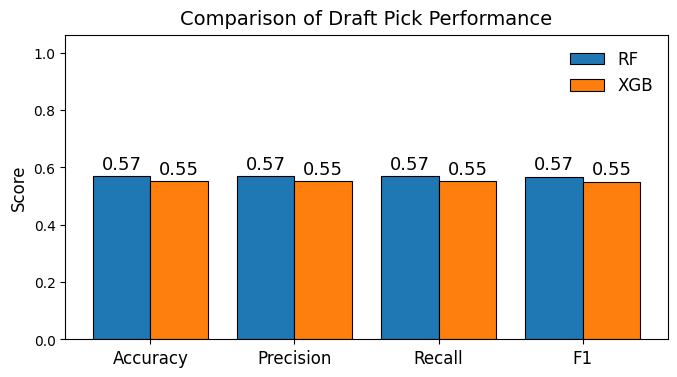

In [66]:
# ===== 4. METRICS COMPARISON CHART (Accuracy/Precision/Recall/F1, RF vs XGB) =====
rf_pred = models["RandomForestClassifier"].predict(X_test)
xgb_pred = models["XGBoost"].predict(X_test)

rf_prob = models["RandomForestClassifier"].predict_proba(X_test)[:, 1]
xgb_prob = models["XGBoost"].predict_proba(X_test)[:, 1]

# Macro average used so both classes (Blue/Red) are weighted equally
# regardless of class imbalance in the test set
rf_scores = [
  accuracy_score(y_test, rf_pred),
  precision_score(y_test, rf_pred, average='macro'),
  recall_score(y_test, rf_pred, average='macro'),
  f1_score(y_test, rf_pred, average='macro'),
  ]

xgb_scores = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred, average='macro'),
    recall_score(y_test, xgb_pred, average='macro'),
    f1_score(y_test, xgb_pred, average='macro'),
  ]

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics)) * 0.8
width = 0.32

fig, ax = plt.subplots(figsize=(6.8, 3.8))
colors_rf = '#1f77b4'
colors_xgb = '#ff7f0e'

ax.bar(x - width/2, rf_scores, width,
       label="RF", color=colors_rf,
       edgecolor='black', linewidth=0.8)

ax.bar(x + width/2, xgb_scores, width,
       label="XGB", color=colors_xgb,
       edgecolor='black', linewidth=0.8)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparison of Draft Pick Performance", fontsize=14, pad=8)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=12, loc='upper right', frameon=False)
ax.set_ylim(0, 1.06)

# Annotate each bar with its score value
for i, v in enumerate(rf_scores):
    ax.text(
        x[i] - width/2,
        v + 0.025,
        f"{v:.2f}",
        ha="center",
        fontsize=13,
        color='black'
    )

for i, v in enumerate(xgb_scores):
    ax.text(
        x[i] + width/2,
        v + 0.025,
        f"{v:.2f}",
        ha="center",
        fontsize=13,
        color='black'
    )

plt.tight_layout(pad=0.8)
plt.show()

In [67]:
# ===== 5. PERSIST TRAINED MODELS =====

# XGBoost is saved via its native .json format instead of pickle, since XGBoost's
# pickle output is tied to the exact library version used to save it and can fail
# to load (or silently behave differently) after a version upgrade.

# json is XGBoost's officially recommended format for long-term/cross-version storage.
# RandomForestClassifier has no native serialization format (it's a plain sklearn
# object), so it's still saved via pickle — this is standard practice for sklearn
# models, just be aware it's tied to the sklearn version used here.
os.makedirs("saved_models", exist_ok=True)

print("=== Simpan SEMUA model ===")
for name, model in models.items():
    if isinstance(model, XGBClassifier):
        filename = f"saved_models/draftpick_model_{name}.json"
        model.save_model(filename)
    else:
        filename = f"saved_models/draftpick_model_{name}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(model, f)
    print(f"Model ({name}) disimpan ke: {filename}")

=== Simpan SEMUA model ===
Model (RandomForestClassifier) disimpan ke: saved_models/draftpick_model_RandomForestClassifier.pkl
Model (XGBoost) disimpan ke: saved_models/draftpick_model_XGBoost.json


## Evaluation Metrics

In [68]:
# Load the best performing models.
# XGBoost is loaded via its native .json format (matching how it was saved
# in the training section) — an empty XGBClassifier instance is created first,
# then load_model() reads the saved weights into it.
loaded_xgb_model_dp = XGBClassifier()
loaded_xgb_model_dp.load_model("saved_models/draftpick_model_XGBoost.json")

# RandomForestClassifier has no native format, so it's still loaded via pickle
with open("saved_models/draftpick_model_RandomForestClassifier.pkl", "rb") as f:
    loaded_rfc_model_dp = pickle.load(f)

print("Loaded XGBoost model:", loaded_xgb_model_dp)
print("Loaded RandomForestClassifier model:", loaded_rfc_model_dp)

Loaded XGBoost model: XGBClassifier(base_score=[0.5244123], booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['float', 'float', 'float', 'float', 'float',
                             'float', 'float', 'float', 'float', 'float',
                             'float', 'float'],
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Loaded RandomForestClassifier 

### Correlation Analysis

diff_strong_score <=> diff_weak_score : -0.98


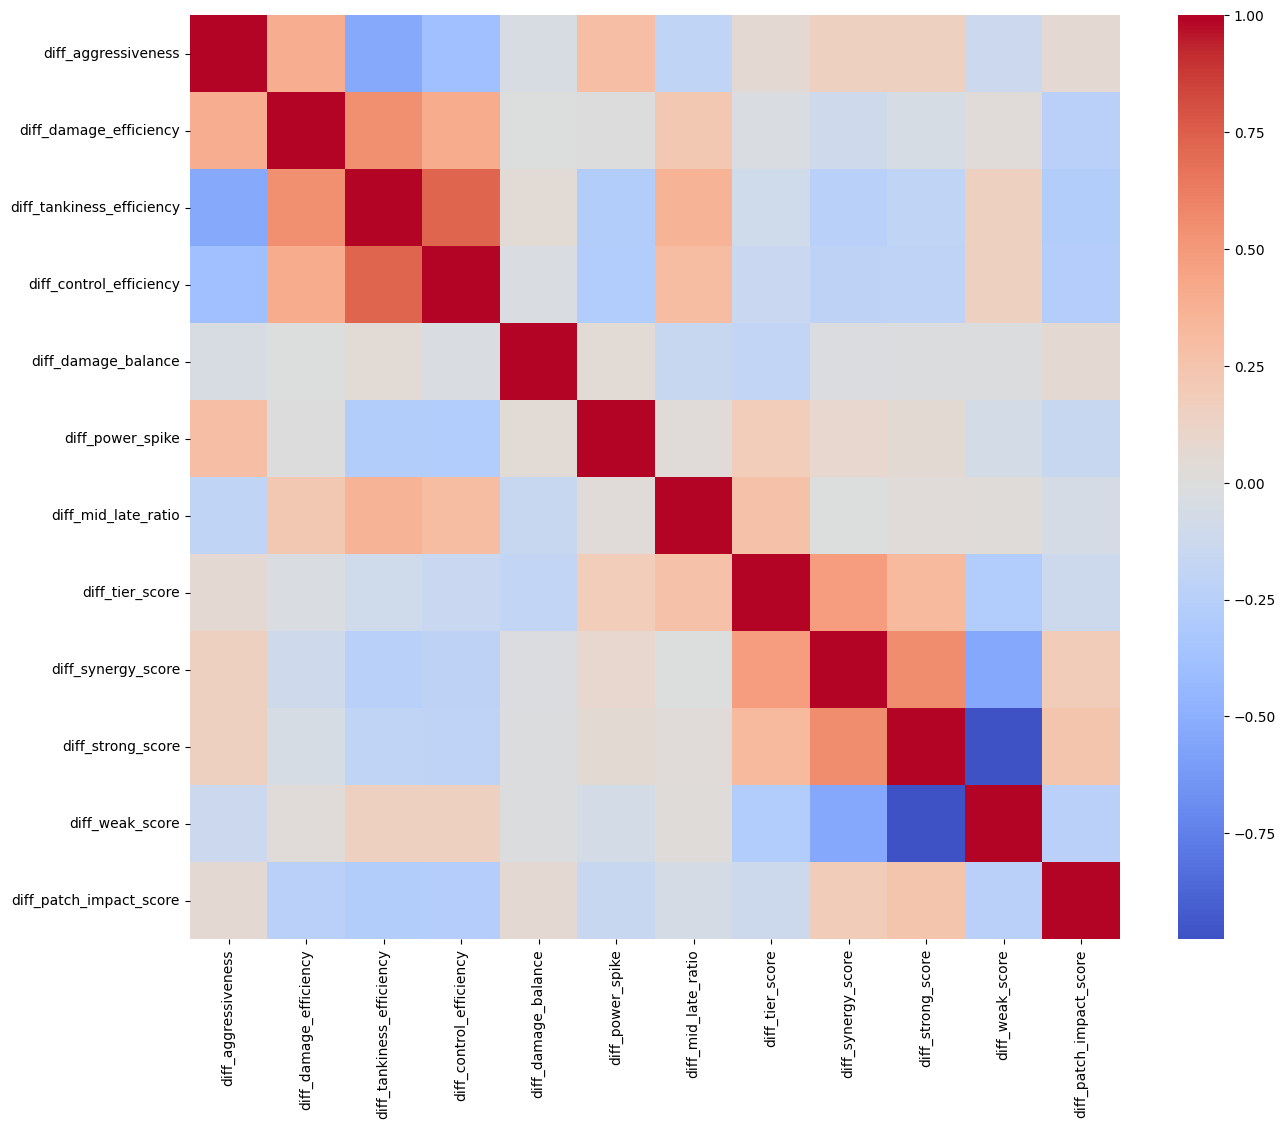

In [69]:
# Compute pairwise correlation between all features, then flag pairs with
# |correlation| > 0.85 as candidates for redundancy (multicollinearity check)
df_corr = X_train.corr()

# Collect column pairs with high correlation
high_corr_pairs = []
for i in range(len(df_corr.columns)):
    for j in range(i+1, len(df_corr.columns)):
        if abs(df_corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((df_corr.columns[i], df_corr.columns[j], df_corr.iloc[i, j]))

# Print the results
for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1} <=> {col2} : {corr_val:.2f}")

# Correlation heatmap visualization
plt.figure(figsize=(15,12))
sns.heatmap(df_corr, annot=False, cmap='coolwarm', center=0)
plt.show()

### Feature Importance

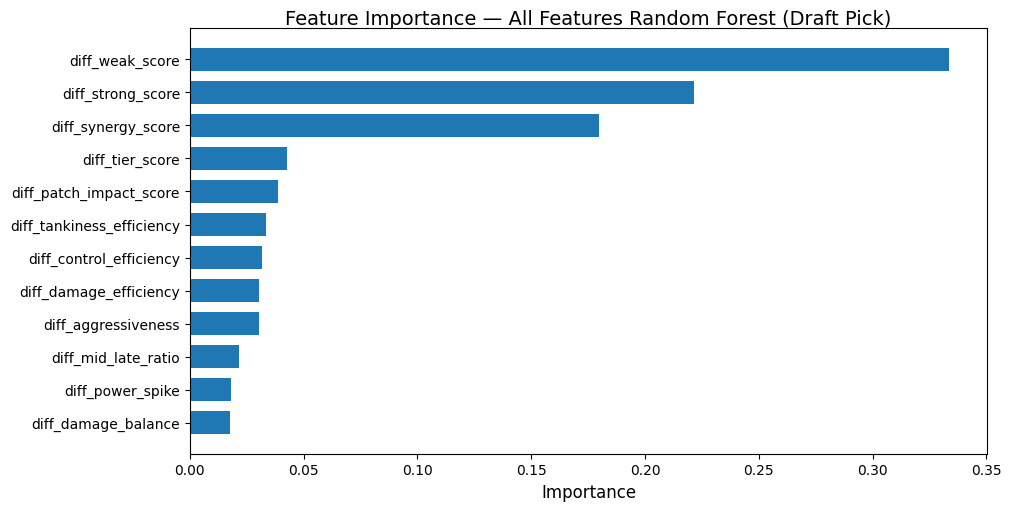

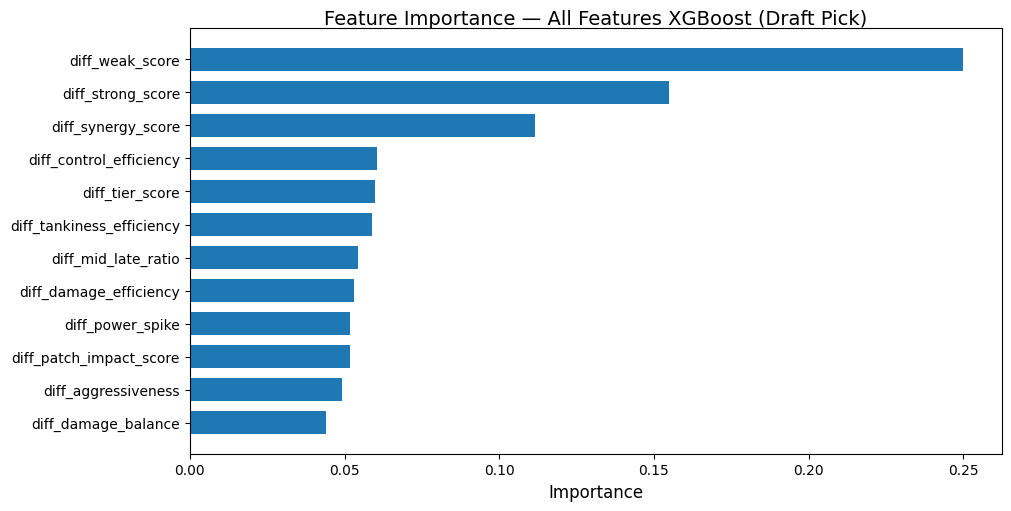

In [70]:
def plot_feature_importance(importance_df, title, figsize, bar_height,
                             xlabel_fontsize, title_fontsize, tick_fontsize, ytick_fontweight='normal'):
    """Render a horizontal bar chart of feature importances.
    Reused for both the full-size (all features) and compact (top 5, report-ready) versions."""
    plt.figure(figsize=figsize)
    plt.barh(
        importance_df['feature'][::-1],
        importance_df['importance'][::-1],
        height=bar_height
    )
    plt.xlabel('Importance', fontsize=xlabel_fontsize)
    plt.title(title, fontsize=title_fontsize, pad=2)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize, fontweight=ytick_fontweight)
    plt.tight_layout(pad=0.3)
    plt.show()


models = {
    'Random Forest (Draft Pick)': loaded_rfc_model_dp,
    'XGBoost (Draft Pick)': loaded_xgb_model_dp
}

for name, model in models.items():
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    # Version 1: full-size chart, all features, for on-screen inspection
    plot_feature_importance(
        importance,
        title=f'Feature Importance — All Features {name}',
        figsize=(10, 5), bar_height=0.7,
        xlabel_fontsize=12, title_fontsize=14, tick_fontsize=10
    )

    # # Version 2: compact 3.4-inch chart, top 5 only, for report/paper embedding
    # plot_feature_importance(
    #     importance.head(5),
    #     title=f'Top 5 Feature Importance ({name})',
    #     figsize=(4, 2.0), bar_height=0.55,
    #     xlabel_fontsize=7, title_fontsize=8, tick_fontsize=6, ytick_fontweight='bold'
    # )

### ROC-AUC Analysis

ROC-AUC XGB: 0.5786
ROC-AUC RF : 0.5619


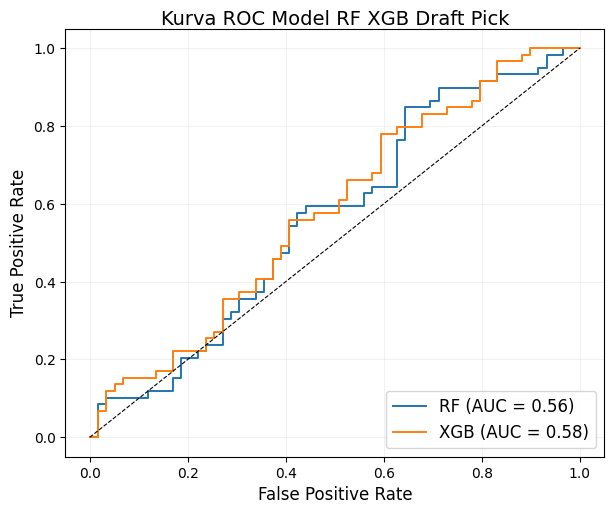

In [71]:
def plot_roc_curve(fpr_rf, tpr_rf, auc_rf, fpr_xgb, tpr_xgb, auc_xgb,
                    title, figsize, line_width, diagonal_width,
                    label_fontsize, title_fontsize, tick_fontsize, legend_fontsize, grid_alpha):
    """Render the RF vs XGBoost ROC curve comparison.
    Reused for both the full-size and compact (report-ready) versions."""
    plt.figure(figsize=figsize)

    plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.2f})", linewidth=line_width)
    plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc_xgb:.2f})", linewidth=line_width)

    # Diagonal reference line (random-guess baseline)
    plt.plot([0, 1], [0, 1], "k--", linewidth=diagonal_width)

    plt.xlabel("FPR" if figsize[0] < 4 else "False Positive Rate", fontsize=label_fontsize)
    plt.ylabel("TPR" if figsize[0] < 4 else "True Positive Rate", fontsize=label_fontsize)
    plt.title(title, fontsize=title_fontsize, pad=2)

    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    plt.legend(loc="lower right", prop={'size': legend_fontsize})
    plt.grid(alpha=grid_alpha, linewidth=0.4)

    plt.tight_layout(pad=0.2)
    plt.show()


# Predict probabilities
y_pred_proba_xgb = loaded_xgb_model_dp.predict_proba(X_test)[:, 1]
y_pred_proba_rf  = loaded_rfc_model_dp.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for each model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f"ROC-AUC XGB: {roc_auc_xgb:.4f}")
print(f"ROC-AUC RF : {roc_auc_rf:.4f}")

# Version 1: full-size ROC curve for on-screen inspection
plot_roc_curve(
    fpr_rf, tpr_rf, roc_auc_rf, fpr_xgb, tpr_xgb, roc_auc_xgb,
    title="Kurva ROC Model RF XGB Draft Pick",
    figsize=(6, 5), line_width=1.4, diagonal_width=0.8,
    label_fontsize=12, title_fontsize=14, tick_fontsize=10, legend_fontsize=12, grid_alpha=0.3
)

# # Version 2: compact 3.4-inch ROC curve for report/paper embedding
# plot_roc_curve(
#     fpr_rf, tpr_rf, roc_auc_rf, fpr_xgb, tpr_xgb, roc_auc_xgb,
#     title="ROC Draft Pick RF vs XGB",
#     figsize=(3.4, 2.4), line_width=1, diagonal_width=0.7,
#     label_fontsize=7, title_fontsize=8, tick_fontsize=6, legend_fontsize=10, grid_alpha=0.25
# )

# In-Game Model Pipeline

## Initialize Last Snapshot

In [72]:
def duration_to_minutes(s):
    """Convert a game duration string formatted as 'H.MM.SS' into total minutes (float).
    Example: '0.23.45' -> 23.75 minutes."""
    h, m, s = map(int, s.split('.'))
    return h*60 + m + s/60

def get_last_snapshot(minute):
    """
    Determine which snapshot stage (9, 12, 15, or 18 minutes) represents the
    LAST available snapshot before the game ended, based on actual game duration.

    Snapshots are taken at fixed intervals (9/12/15/18 min), but games end at
    varying durations, so this maps a game's actual length to the closest
    snapshot stage that would have been captured before it ended.
    """

    if 9.83 <= minute <= 12.82:    # 9:50 - 12:49
        return 9
    elif 12.83 <= minute <= 15.82: # 12:50 - 15:49
        return 12
    elif 15.83 <= minute <= 18.82: # 15:50 - 18:49
        return 15
    elif minute >= 18.83:          # >= 18:50
        return 18
    else:                          # game duration shorter than 9:50
        return 9

In [73]:
# Convert game duration to minutes and determine each match's last available snapshot stage
msc25_df_snapshots["game_duration_min"] = msc25_df_snapshots["game_duration"].apply(duration_to_minutes)
msc25_df_snapshots["last_snapshot"] = msc25_df_snapshots["game_duration_min"].apply(get_last_snapshot)

# Keep only the row matching each game's last snapshot stage (one row per game_id),
# used later to evaluate model performance right before the game actually ended
msc25_df_last_snapshots = msc25_df_snapshots[msc25_df_snapshots["snapshot_stage"] == msc25_df_snapshots["last_snapshot"]]

In [74]:
msc25_df_last_snapshots.head()

,id,no,match_id,game_id,tournament,stage,region,date_wib,best_of,game_number,blue_team,red_team,blue_explaner,blue_jungler,blue_midlaner,blue_goldlaner,blue_roamer,red_explaner,red_jungler,red_midlaner,red_goldlaner,red_roamer,blue_bans,red_bans,winner,winner_team,game_duration,patch_version,days_since_patch,snapshot_stage,blue_first_blood,red_first_blood,blue_total_gold,red_total_gold,blue_explaner_kda,blue_jungler_kda,blue_midlaner_kda,blue_goldlaner_kda,blue_roamer_kda,red_explaner_kda,red_jungler_kda,red_midlaner_kda,red_goldlaner_kda,red_roamer_kda,blue_explaner_level,blue_jungler_level,blue_midlaner_level,blue_goldlaner_level,blue_roamer_level,red_explaner_level,red_jungler_level,red_midlaner_level,red_goldlaner_level,red_roamer_level,blue_first_turret,red_first_turret,blue_total_turret,red_total_turret,blue_first_inhibitor,red_first_inhibitor,blue_total_inhibitor,red_total_inhibitor,blue_first_turtle,red_first_turtle,blue_total_turtle,red_total_turtle,blue_first_lord,red_first_lord,blue_total_lord,red_total_lord,objective_status_lord,objective_countdown_lord,game_duration_min,last_snapshot
3,4,1,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,1,Rare Atom,Team Falcons,Uranus,Hayabusa,Zhask,Irithel,Baxia,Badang,Guinevere,Zhuxin,Granger,Mathilda,"Pharsa,Kalea,Fredrinn,Joy,Chou","Lancelot,Yi Sun-shin,Wanwan,Kimmy,Zetian",red,Team Falcons,00.19.38,Patch 1.9.91.1,8,18,False,True,46100,50400,0_3_2,2_1_2,1_2_2,0_1_3,1_2_2,0_1_5,2_1_6,1_1_6,4_0_3,2_1_7,15,15,15,15,13,15,15,15,15,15,False,True,2,6,False,True,0,3,True,False,2,1,False,True,0,2,waiting,102,19.633333,18
7,8,2,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-2,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,2,Team Falcons,Rare Atom,Badang,Fredrinn,Pharsa,Granger,Kalea,Esmeralda,Yi Sun-shin,Zetian,Irithel,Hylos,"Lancelot,Wanwan,Arlott,Gatotkaca,Phoveus","Baxia,Uranus,Mathilda,Hayabusa,Joy",red,Rare Atom,00.24.24,Patch 1.9.91.1,8,18,True,False,48800,46300,0_2_5,1_0_5,3_0_7,2_0_5,5_2_3,0_3_3,1_1_3,0_1_3,3_2_0,0_4_3,14,15,15,15,14,15,15,14,15,13,True,False,6,4,False,False,0,0,True,False,2,1,True,False,1,1,spawned,0,24.400000,18
8,9,3,MSC2025WCA_R01-M001,MSC2025WCA_R01-M001-3,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 16.00,3,3,Rare Atom,Team Falcons,Lapu-Lapu,Yi Sun-shin,Kimmy,Moskov,Baxia,Hilda,Uranus,Zhuxin,Granger,Angela,"Pharsa,Kalea,Mathilda,Hayabusa,Joy","Lancelot,Wanwan,Zetian,Esmeralda,Gloo",blue,Rare Atom,00.11.23,Patch 1.9.91.1,8,9,True,False,29800,20700,4_0_5,2_0_7,1_0_5,1_0_1,1_1_7,0_3_0,0_3_1,0_2_1,0_0_1,1_1_0,11,13,10,12,9,9,10,9,10,8,True,False,5,0,False,False,0,0,True,False,3,0,False,False,0,0,waiting,18,11.383333,9
10,11,4,MSC2025WCA_R01-M002,MSC2025WCA_R01-M002-1,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 18.00,3,1,Legion Esports,The MongolZ,Uranus,Yi Sun-shin,Novaria,Granger,Gatotkaca,Yu Zhong,Fredrinn,Kimmy,Bruno,Franco,"Phoveus,Zhuxin,Mathilda,Masha,Arlott","Wanwan,Baxia,Kalea,Zetian,Pharsa",red,The MongolZ,00.13.50,Patch 1.9.91.1,8,12,False,True,29600,35400,0_1_0,0_1_2,1_0_1,1_4_1,0_1_2,1_1_2,1_0_4,1_1_4,3_0_2,1_0_5,11,14,11,12,10,12,13,13,14,11,False,True,1,6,False,True,0,1,False,True,1,2,False,True,0,1,waiting,12,13.833333,12
13,14,5,MSC2025WCA_R01-M002,MSC2025WCA_R01-M002-2,MSC 2025,Wildcard,Saudi Arabia,10/07/2025 18.00,3,2,Legion Esports,The MongolZ,Uranus,Joy,Pharsa,Moskov,Chou,Lapu-Lapu,Fanny,Valentina,Yi Sun-shin,Badang,"Phoveus,Zhuxin,Mathilda,Zetian,Harith","Wanwan,Baxia,Kalea,Angela,Esmeralda",blue,Legion Esports,00.16.39,Patch 1.9.91.1,8,15,True,False,46700,37800,1_0_7,3_1_5,4_1_6,4_2_3,2_2_5,3_2_1,2_3_0,0_3_4,1_3_2,0_3_3,13,15,14,15,12,13,14,14,15,12,True,False,6,2,True,False,2,0,True,False,2,1,True,False,1,0,spawned,0,16.650000,15


## Feature Engineering

### Feature Mapping Table

|         Feature         |       Name Used      | Name Used with diff_ |                                       Observations                                      |
|:-----------------------:|:--------------------:|----------------------|:---------------------------------------------------------------------------------------:|
| Snapshot Stage          | snapshot_stage       | snapshot_stage       | snapshot for minute in-game                                                             |
| Total team gold         | total_[side]_gold    | diff_gold            | Percentage of total gold in game, one for blue and one for red side                     |
| Total team kills        | total_[side]_kills   | diff_kills           | Percentage of total kills in the game for each side                                     |
| Median kills per player | med_[side]_kills     | diff_med_kills       | Median percentage of kills per each position of each side                               |
| Median team level       | med_[side]_level     | diff_med_level       | Median percentage of level per side                                                     |
| First blood             | [side]_first_blood   | diff_first_blood     | Boolean of whether the team got first blood or not                                      |
| First tower             | [side]_first_turret  | diff_first_turret    | Boolean of whether or not the team took the first turret taken in the game              |
| Total team towers       | total_[side]_turret  | diff_turret          | Percentage of towers taken (out of all towers taken in the game) per side               |
| First Inhibitor         | [side]_first_inhib   | diff_first_inhib     | Boolean of whether or not the team was the first to take an inhibitor in the enemy base |
| Total Inhibitors        | total_[side]_inhibs  | diff_inhibs          | Total percentage of inhibitors taken by each team                                       |
| First turtle            | [side]_first_turtle  | diff_first_turtle    | Boolean of whether the team got the first turtle or not                                 |
| Total turtles           | total_[side]_turtles | diff_turtles         | Total percentage of turtle (out of all taken) per side                                  |
| First lord              | [side]_first_lord    | diff_first_lord      | Boolean of whether or not the team to the first Lord or not                             |
| Total lords             | total_[side]_lords   | diff_lords           | Total percentage of lords taken by each side                                            |

### Initialize Feature Engineering

In [75]:
def build_features(df):
    """
    Build in-game snapshot features per match-snapshot row, following the
    Feature Mapping Table above. For each numeric stat (gold, kills, turret,
    inhibitor, turtle, lord), computes:
      - a normalized total per side (ratio of that side's total vs both sides combined)
      - a diff_* version (red_ratio - blue_ratio), used as the actual model input

    For boolean "first_*" events (first blood/turret/inhib/turtle/lord),
    computes diff_* as (red_flag - blue_flag).

    KDA fields are parsed per role, then reduced to:
      - total kills (normalized ratio per side)
      - median per-role kill ratio (head-to-head comparison per lane)

    Parameters
    ----------
    df : pd.DataFrame
        In-game snapshot data (one row per match per snapshot_stage), with
        blue_*/red_* raw stat columns and per-role KDA string columns.

    Returns
    -------
    pd.DataFrame
        One row per match-snapshot, containing 'no', 'winner' (0=blue, 1=red),
        'snapshot_stage', raw normalized blue_*/red_* totals, and all diff_*
        features used for modeling.
    """

    roles = ["explaner", "jungler", "midlaner", "goldlaner", "roamer"]

    def parse_kda_field(s):
        """Safely parse a 'k_d_a' string (e.g. '5_2_10') into (kills, deaths, assists).
        Returns (0, 0, 0) for NaN, malformed strings, or parsing errors."""
        try:
            if pd.isna(s):
                return (0, 0, 0)
            parts = s.split("_")
            return tuple(int(p) if p.isdigit() or (p and p[0] == "-" and p[1:].isdigit()) else 0 for p in (parts + ["0", "0", "0"])[:3])
        except Exception:
            return (0, 0, 0)

    def safe_ratio(a, b):
        """Return a / (a + b), or 0 if both are zero. Used to normalize each
        side's stat as a share of the combined total (guards against div-by-zero)."""
        denom = a + b
        return a / denom if denom != 0 else 0

    features = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Building features"):
        # Parse per-role KDA for both sides
        blue_kda = [parse_kda_field(row.get(f'blue_{r}_kda')) for r in roles]
        red_kda  = [parse_kda_field(row.get(f'red_{r}_kda'))  for r in roles]

        blue_kills   = [k for k, _, _ in blue_kda]
        red_kills   = [k for k, _, _ in red_kda]

        # Team-level kill totals, normalized as each side's share of combined kills
        total_blue_kills = safe_ratio(sum(blue_kills), sum(red_kills))
        total_red_kills  = safe_ratio(sum(red_kills),  sum(blue_kills))

        # Per-role head-to-head kill ratio, then take the median across roles
        def median_head2head(b_list, r_list):
            """Compute per-role (lane-matched) kill ratio for both sides,
            then return the median ratio across all 5 roles."""
            ratios_b = []
            ratios_r = []
            for b, r in zip(b_list, r_list):
                if (b + r) != 0:
                    ratios_b.append(safe_ratio(b, r))
                    ratios_r.append(safe_ratio(r, b))
                else:
                    ratios_b.append(0)
                    ratios_r.append(0)
            return float(np.median(ratios_b)), float(np.median(ratios_r))

        med_blue_kills, med_red_kills = median_head2head(blue_kills, red_kills)

        # Median team level (per role, per side)
        blue_lvls = [row.get(f'blue_{r}_level', 0) for r in roles]
        red_lvls  = [row.get(f'red_{r}_level', 0)  for r in roles]
        med_blue_level = float(np.median(blue_lvls))
        med_red_level  = float(np.median(red_lvls))

        # Objective totals (gold, turret, inhibitor, turtle, lord), normalized per side
        total_blue_gold = safe_ratio(row.get("blue_total_gold", 0), row.get("red_total_gold", 0))
        total_red_gold  = safe_ratio(row.get("red_total_gold", 0), row.get("blue_total_gold", 0))

        total_blue_turret = safe_ratio(row.get("blue_total_turret", 0), row.get("red_total_turret", 0))
        total_red_turret  = safe_ratio(row.get("red_total_turret", 0), row.get("blue_total_turret", 0))

        total_blue_inhibs = safe_ratio(row.get("blue_total_inhibitor", 0), row.get("red_total_inhibitor", 0))
        total_red_inhibs  = safe_ratio(row.get("red_total_inhibitor", 0), row.get("blue_total_inhibitor", 0))

        total_blue_turtles = safe_ratio(row.get("blue_total_turtle", 0), row.get("red_total_turtle", 0))
        total_red_turtles  = safe_ratio(row.get("red_total_turtle", 0), row.get("blue_total_turtle", 0))

        total_blue_lords = safe_ratio(row.get("blue_total_lord", 0), row.get("red_total_lord", 0))
        total_red_lords  = safe_ratio(row.get("red_total_lord", 0), row.get("blue_total_lord", 0))

        # diff_* features: red side's ratio minus blue side's ratio (matches the
        # convention used in get_diff_features() in the Draft Pick pipeline —
        # positive = advantage Red)
        diff_features = {}
        for k, v in {
            "gold": (total_red_gold, total_blue_gold),
            "kills": (total_red_kills, total_blue_kills),
            "med_kills": (med_red_kills, med_blue_kills),
            "med_level": (med_red_level, med_blue_level),
            "turret": (total_red_turret, total_blue_turret),
            "inhibs": (total_red_inhibs, total_blue_inhibs),
            "turtles": (total_red_turtles, total_blue_turtles),
            "lords": (total_red_lords, total_blue_lords),
        }.items():
            diff_features[f"diff_{k}"] = v[0] - v[1]

        # diff features for boolean "first_..." events
        diff_features["diff_first_blood"]  = int(row.get("red_first_blood", 0))  - int(row.get("blue_first_blood", 0))
        diff_features["diff_first_turret"] = int(row.get("red_first_turret", 0)) - int(row.get("blue_first_turret", 0))
        diff_features["diff_first_inhib"]  = int(row.get("red_first_inhibitor", 0)) - int(row.get("blue_first_inhibitor", 0))
        diff_features["diff_first_turtle"] = int(row.get("red_first_turtle", 0)) - int(row.get("blue_first_turtle", 0))
        diff_features["diff_first_lord"]   = int(row.get("red_first_lord", 0))   - int(row.get("blue_first_lord", 0))


        row_features = {
            "no": row.get("no"),
            "winner": 0 if row.get("winner") == "blue" else 1,
            "snapshot_stage": row.get("snapshot_stage"),

            "total_blue_gold": total_blue_gold,
            "total_blue_kills": total_blue_kills,
            "med_blue_kills": med_blue_kills,
            "med_blue_level": med_blue_level,
            "blue_first_blood": row.get("blue_first_blood"),
            "blue_first_turret": row.get("blue_first_turret"),
            "total_blue_turret": total_blue_turret,
            "blue_first_inhib": row.get("blue_first_inhibitor"),
            "total_blue_inhibs": total_blue_inhibs,
            "blue_first_turtle": row.get("blue_first_turtle"),
            "total_blue_turtles": total_blue_turtles,
            "blue_first_lord": row.get("blue_first_lord"),
            "total_blue_lords": total_blue_lords,


            "total_red_gold": total_red_gold,
            "total_red_kills": total_red_kills,
            "med_red_kills": med_red_kills,
            "med_red_level": med_red_level,
            "red_first_blood": row.get("red_first_blood"),
            "red_first_turret": row.get("red_first_turret"),
            "total_red_turret": total_red_turret,
            "red_first_inhib": row.get("red_first_inhibitor"),
            "total_red_inhibs": total_red_inhibs,
            "red_first_turtle": row.get("red_first_turtle"),
            "total_red_turtles": total_red_turtles,
            "red_first_lord": row.get("red_first_lord"),
            "total_red_lords": total_red_lords,
        }
        row_features.update(diff_features)

        features.append(row_features)

    return pd.DataFrame(features)

### Execute Feature Engineering

In [76]:
# Build features for the TRAIN set: all snapshots from Qualification stage
features_df_train = build_features(qualification_msc25_df_snapshots)

Building features: 100%|██████████| 1348/1348 [00:00<00:00, 2073.28it/s]


In [77]:
features_df_train.head()

,no,winner,snapshot_stage,total_blue_gold,total_blue_kills,med_blue_kills,med_blue_level,blue_first_blood,blue_first_turret,total_blue_turret,blue_first_inhib,total_blue_inhibs,blue_first_turtle,total_blue_turtles,blue_first_lord,total_blue_lords,total_red_gold,total_red_kills,med_red_kills,med_red_level,red_first_blood,red_first_turret,total_red_turret,red_first_inhib,total_red_inhibs,red_first_turtle,total_red_turtles,red_first_lord,total_red_lords,diff_gold,diff_kills,diff_med_kills,diff_med_level,diff_turret,diff_inhibs,diff_turtles,diff_lords,diff_first_blood,diff_first_turret,diff_first_inhib,diff_first_turtle,diff_first_lord
0,1,0,9,0.534113,0.625000,0.500000,10.0,True,True,0.666667,False,0.0,True,1.0,False,0.0,0.465887,0.375000,0.333333,9.0,False,False,0.333333,False,0.0,False,0.0,False,0.0,-0.068226,-0.250000,-0.166667,-1.0,-0.333333,0.0,-1.0,0.0,-1,-1,0,-1,0
1,1,0,12,0.560801,0.666667,0.666667,12.0,True,True,0.750000,True,1.0,True,1.0,True,1.0,0.439199,0.333333,0.285714,11.0,False,False,0.250000,False,0.0,False,0.0,False,0.0,-0.121602,-0.333333,-0.380952,-1.0,-0.500000,-1.0,-1.0,-1.0,-1,-1,-1,-1,-1
2,2,0,9,0.582205,0.916667,1.000000,11.0,True,False,0.714286,False,0.0,True,1.0,False,0.0,0.417795,0.083333,0.000000,9.0,False,True,0.285714,False,0.0,False,0.0,False,0.0,-0.164410,-0.833333,-1.000000,-2.0,-0.428571,0.0,-1.0,0.0,-1,1,0,-1,0
3,3,1,9,0.548902,0.727273,0.833333,10.0,True,True,1.000000,False,0.0,True,1.0,False,0.0,0.451098,0.272727,0.000000,9.0,False,False,0.000000,False,0.0,False,0.0,False,0.0,-0.097804,-0.454545,-0.833333,-1.0,-1.000000,0.0,-1.0,0.0,-1,-1,0,-1,0
4,3,1,12,0.512337,0.625000,0.666667,12.0,True,True,0.750000,False,0.0,True,1.0,False,0.0,0.487663,0.375000,0.300000,11.0,False,False,0.250000,False,0.0,False,0.0,True,1.0,-0.024673,-0.250000,-0.366667,-1.0,-0.500000,0.0,-1.0,1.0,-1,-1,0,-1,1


In [78]:
# Build features for the TEST set: all snapshots from Main Event (across all snapshot stages)
features_df_test = build_features(msc25_df_snapshots)

Building features: 100%|██████████| 304/304 [00:00<00:00, 1451.52it/s]


In [79]:
features_df_test.head()

,no,winner,snapshot_stage,total_blue_gold,total_blue_kills,med_blue_kills,med_blue_level,blue_first_blood,blue_first_turret,total_blue_turret,blue_first_inhib,total_blue_inhibs,blue_first_turtle,total_blue_turtles,blue_first_lord,total_blue_lords,total_red_gold,total_red_kills,med_red_kills,med_red_level,red_first_blood,red_first_turret,total_red_turret,red_first_inhib,total_red_inhibs,red_first_turtle,total_red_turtles,red_first_lord,total_red_lords,diff_gold,diff_kills,diff_med_kills,diff_med_level,diff_turret,diff_inhibs,diff_turtles,diff_lords,diff_first_blood,diff_first_turret,diff_first_inhib,diff_first_turtle,diff_first_lord
0,1,1,9,0.501031,0.285714,0.000000,10.0,False,False,0.666667,False,0.0,True,0.666667,False,0.0,0.498969,0.714286,0.666667,10.0,True,True,0.333333,False,0.0,False,0.333333,False,0.0,-0.002062,0.428571,0.666667,0.0,-0.333333,0.0,-0.333333,0.0,1,1,0,-1,0
1,1,1,12,0.504839,0.285714,0.000000,11.0,False,False,0.666667,False,0.0,True,0.666667,False,0.0,0.495161,0.714286,0.666667,12.0,True,True,0.333333,False,0.0,False,0.333333,False,0.0,-0.009677,0.428571,0.666667,1.0,-0.333333,0.0,-0.333333,0.0,1,1,0,-1,0
2,1,1,15,0.485425,0.300000,0.333333,13.0,False,False,0.250000,False,0.0,True,0.666667,False,0.0,0.514575,0.700000,0.666667,13.0,True,True,0.750000,True,1.0,False,0.333333,True,1.0,0.029151,0.400000,0.333333,0.0,0.500000,1.0,-0.333333,1.0,1,1,1,-1,1
3,1,1,18,0.477720,0.307692,0.333333,15.0,False,False,0.250000,False,0.0,True,0.666667,False,0.0,0.522280,0.692308,0.500000,15.0,True,True,0.750000,True,1.0,False,0.333333,True,1.0,0.044560,0.384615,0.166667,0.0,0.500000,1.0,-0.333333,1.0,1,1,1,-1,1
4,2,1,9,0.521654,0.750000,1.000000,10.0,True,True,0.500000,False,0.0,True,0.666667,False,0.0,0.478346,0.250000,0.000000,10.0,False,False,0.500000,False,0.0,False,0.333333,False,0.0,-0.043307,-0.500000,-1.000000,0.0,0.000000,0.0,-0.333333,0.0,-1,-1,0,-1,0


In [80]:
# Build features for the TEST set, restricted to each match's LAST snapshot only
# (used later to evaluate model performance right before the game ended)
features_df_test_last = build_features(msc25_df_last_snapshots)

Building features: 100%|██████████| 118/118 [00:00<00:00, 1785.16it/s]


## Train Models

In [81]:
# Feature set used for in-game modeling: 'snapshot_stage' plus every diff_*
# feature from build_features() (see the Feature Mapping Table above for
# what each column represents). Note this deliberately excludes the raw
# total_blue_*/total_red_*/blue_first_*/red_first_* columns — same pattern
# as rows_to_keep in the Draft Pick pipeline (keep diffs, drop the raw pair
# they were derived from, to avoid redundant/collinear features).
diff_cols = [
        "snapshot_stage",
        "diff_gold",
        "diff_kills",
        "diff_med_kills",
        "diff_med_level",
        "diff_first_blood",
        "diff_first_turret",
        "diff_turret",
        "diff_first_inhib",
        "diff_inhibs",
        "diff_first_turtle",
        "diff_turtles",
        "diff_first_lord",
        "diff_lords",
    ]

In [82]:
# Slice train/test data down to the selected feature columns
X_train = features_df_train[diff_cols].copy()
X_test = features_df_test[diff_cols].copy()

In [83]:
# Target labels (0=blue win, 1=red win, per the encoding in build_features())
y_train = features_df_train["winner"]
y_test  = features_df_test["winner"]

In [84]:
X_train.columns

Index(['snapshot_stage', 'diff_gold', 'diff_kills', 'diff_med_kills',
       'diff_med_level', 'diff_first_blood', 'diff_first_turret',
       'diff_turret', 'diff_first_inhib', 'diff_inhibs', 'diff_first_turtle',
       'diff_turtles', 'diff_first_lord', 'diff_lords'],
      dtype='object')

In [85]:
X_train.head()

,snapshot_stage,diff_gold,diff_kills,diff_med_kills,diff_med_level,diff_first_blood,diff_first_turret,diff_turret,diff_first_inhib,diff_inhibs,diff_first_turtle,diff_turtles,diff_first_lord,diff_lords
0,9,-0.068226,-0.250000,-0.166667,-1.0,-1,-1,-0.333333,0,0.0,-1,-1.0,0,0.0
1,12,-0.121602,-0.333333,-0.380952,-1.0,-1,-1,-0.500000,-1,-1.0,-1,-1.0,-1,-1.0
2,9,-0.164410,-0.833333,-1.000000,-2.0,-1,1,-0.428571,0,0.0,-1,-1.0,0,0.0
3,9,-0.097804,-0.454545,-0.833333,-1.0,-1,-1,-1.000000,0,0.0,-1,-1.0,0,0.0
4,12,-0.024673,-0.250000,-0.366667,-1.0,-1,-1,-0.500000,0,0.0,-1,-1.0,1,1.0


In [86]:
# Random Forest — same hyperparameters as the Draft Pick pipeline (max_depth=4
# to limit overfitting), but a different random_state (9 vs 28) since this is
# a separate model instance trained on in-game snapshot features
rf = RandomForestClassifier(
        random_state=9,
        n_estimators=100,
        max_depth=4,
    )
rf.fit(X_train, y_train)

# XGBoost — same hyperparameter choices as the Draft Pick pipeline's XGBoost model
xgb = XGBClassifier(
        eval_metric="logloss",
        random_state=9,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        subsample=0.8
    )
xgb.fit(X_train, y_train)

# Persist both models to disk, same convention as the Draft Pick pipeline:
# XGBoost -> native .json (version-portable), RandomForest -> pickle (no native format).
# Filenames prefixed with "ingame_" to avoid colliding with the Draft Pick models
# saved earlier ("draftpick_*").
os.makedirs("saved_models", exist_ok=True)

xgb.save_model("saved_models/ingame_model_XGBoost.json")

with open("saved_models/ingame_model_RandomForestClassifier.pkl", "wb") as f:
    pickle.dump(rf, f)

print("In-game models saved.")

In-game models saved.


In [87]:
# Reload both models from disk and OVERWRITE the `rf`/`xgb` variables in place.
# From this point on, every cell under "Evaluation Models" that references `rf`
# or `xgb` is transparently operating on the reloaded (persisted) model instance,
# not the one still in memory from training above — this verifies the saved
# files actually round-trip correctly and matches the reload pattern used in
# the Draft Pick pipeline's "Evaluation Metrics" section.
xgb = XGBClassifier()
xgb.load_model("saved_models/ingame_model_XGBoost.json")

with open("saved_models/ingame_model_RandomForestClassifier.pkl", "rb") as f:
    rf = pickle.load(f)

print("Loaded XGBoost (In-game) model:", xgb)
print("Loaded RandomForestClassifier (In-game) model:", rf)

Loaded XGBoost (In-game) model: XGBClassifier(base_score=[0.52002966], booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'float', 'float', 'float', 'float', 'int',
                             'int', 'float', 'int', 'float', 'int', 'float',
                             'int', 'float'],
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Loaded Random

## Evaluation Models

### Evaluation per snapshot

In [88]:
# Evaluate both models separately for each snapshot stage (9/12/15/18 min),
# to see how prediction accuracy changes as the game progresses
results = []

for stage in [9, 12, 15, 18]:
    df_stage = features_df_test[features_df_test["snapshot_stage"] == stage]
    X_test = df_stage[diff_cols].copy()
    y_test = df_stage["winner"]

    rf_probs  = rf.predict_proba(X_test)[:, 1]
    xgb_probs = xgb.predict_proba(X_test)[:, 1]

    rf_pred  = rf.predict(X_test)
    xgb_pred = xgb.predict(X_test)

    # Store Random Forest metrics
    results.append({
        "Snapshot": stage,
        "Model": "Random Forest",
        "Accuracy": round(accuracy_score(y_test, rf_pred), 2),
        "Precision": round(precision_score(y_test, rf_pred, average='macro'), 2),
        "Recall": round(recall_score(y_test, rf_pred, average='macro'), 2),
        "F1-score": round(f1_score(y_test, rf_pred, average='macro'), 2),
        "ROC AUC": round(roc_auc_score(y_test, rf_probs), 2)
    })

    # Store XGBoost metrics
    results.append({
        "Snapshot": stage,
        "Model": "XGBoost",
        "Accuracy": round(accuracy_score(y_test, xgb_pred), 2),
        "Precision": round(precision_score(y_test, xgb_pred, average='macro'), 2),
        "Recall": round(recall_score(y_test, xgb_pred, average='macro'), 2),
        "F1-score": round(f1_score(y_test, xgb_pred, average='macro'), 2),
        "ROC AUC": round(roc_auc_score(y_test, xgb_probs), 2)
    })

metrics_df_snapshots = pd.DataFrame(results)
metrics_df_snapshots


,Snapshot,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,9,Random Forest,0.76,0.76,0.76,0.76,0.86
1,9,XGBoost,0.75,0.76,0.75,0.74,0.85
2,12,Random Forest,0.83,0.84,0.83,0.83,0.87
3,12,XGBoost,0.83,0.84,0.83,0.83,0.87
4,15,Random Forest,0.75,0.75,0.75,0.75,0.85
5,15,XGBoost,0.76,0.78,0.77,0.76,0.87
6,18,Random Forest,0.72,0.74,0.74,0.72,0.74
7,18,XGBoost,0.66,0.72,0.68,0.64,0.78


In [89]:
# Reshape into a wide table: rows = Snapshot, columns = (Model, Metric)
pivot_df = metrics_df_snapshots.pivot_table(
    index="Snapshot",
    columns="Model",
    values=["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]
)

# Swap levels so Model becomes the top column level (easier to scan per-model)
pivot_df = pivot_df.swaplevel(axis=1).sort_index(axis=1, level=0)

# Reorder metric columns into a more readable sequence
desired_order = ['Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1-score']
pivot_df = pivot_df.reindex(columns=desired_order, level=1)

pivot_df


Model    Random Forest                                    XGBoost          \
              Accuracy ROC AUC Precision Recall F1-score Accuracy ROC AUC   
Snapshot                                                                    
9                 0.76    0.86      0.76   0.76     0.76     0.75    0.85   
12                0.83    0.87      0.84   0.83     0.83     0.83    0.87   
15                0.75    0.85      0.75   0.75     0.75     0.76    0.87   
18                0.72    0.74      0.74   0.74     0.72     0.66    0.78   

Model                               
         Precision Recall F1-score  
Snapshot                            
9             0.76   0.75     0.74  
12            0.84   0.83     0.83  
15            0.78   0.77     0.76  
18            0.72   0.68     0.64

### Evaluation last snapshot

In [90]:
X_test_last  = features_df_test_last[diff_cols].copy()
y_test_last  = features_df_test_last["winner"]

# Predicted probabilities (for ROC-AUC)
rf_probs  = rf.predict_proba(X_test_last)[:, 1]
xgb_probs = xgb.predict_proba(X_test_last)[:, 1]

# Predicted class labels
rf_pred  = rf.predict(X_test_last)
xgb_pred = xgb.predict(X_test_last)

# Compute core metrics for both models on the last-snapshot-only test set
metrics = {
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        round(accuracy_score(y_test_last, rf_pred), 2),
        round(accuracy_score(y_test_last, xgb_pred), 2),
    ],
    "Precision": [
        round(precision_score(y_test_last, rf_pred, average='macro'), 2),
        round(precision_score(y_test_last, xgb_pred, average='macro'), 2),
    ],
    "Recall": [
        round(recall_score(y_test_last, rf_pred, average='macro'), 2),
        round(recall_score(y_test_last, xgb_pred, average='macro'), 2),
    ],
    "F1-score": [
        round(f1_score(y_test_last, rf_pred, average='macro'), 2),
        round(f1_score(y_test_last, xgb_pred, average='macro'), 2),
    ],
    "ROC AUC": [
        round(roc_auc_score(y_test_last, rf_probs), 2),
        round(roc_auc_score(y_test_last, xgb_probs), 2),
    ]
}

metrics_df_snapshots_last = pd.DataFrame(metrics)

# Reorder columns to match metrics_df_snapshots' column order
desired_order = ['Model', 'Accuracy', 'ROC AUC', 'Precision', 'Recall', 'F1-score']
metrics_df_snapshots_last = metrics_df_snapshots_last[desired_order]

metrics_df_snapshots_last



,Model,Accuracy,ROC AUC,Precision,Recall,F1-score
0,Random Forest,0.88,0.94,0.89,0.88,0.88
1,XGBoost,0.84,0.94,0.86,0.84,0.84


### Evaluation Plots

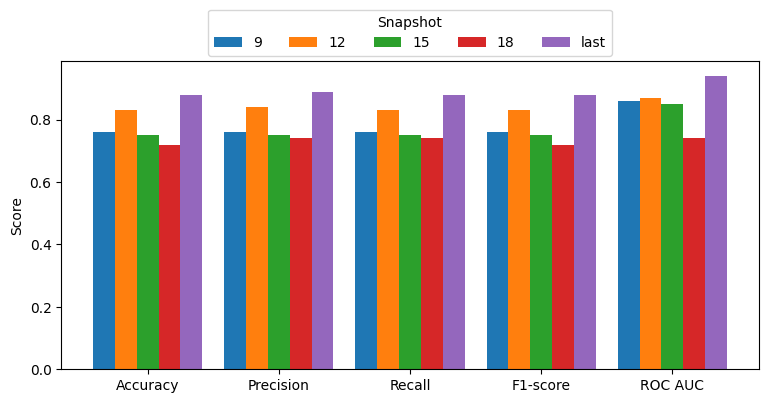

In [91]:
# Combine the per-snapshot metrics (9/12/15/18) with the last-snapshot metrics
# into a single dataframe for plotting
metrics_df_snapshots_last['Snapshot'] = 'last'
metrics_df_snapshots['Snapshot'] = metrics_df_snapshots['Snapshot'].astype(str)
metrics_df_all = pd.concat([metrics_df_snapshots, metrics_df_snapshots_last], ignore_index=True)

# Filter to Random Forest only for this chart
rf_df = metrics_df_all[metrics_df_all['Model'] == 'Random Forest']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']
x = np.arange(len(metrics))  * 0.9 # base x position per metric
width = 0.15 # bar width

snapshots = ['9','12','15','18','last']

fig, ax = plt.subplots(figsize=(9,4))

# One grouped bar per snapshot stage, across all 5 metrics
for i, snap in enumerate(snapshots):
    snap_values = rf_df[rf_df['Snapshot']==snap][metrics].values.flatten()
    ax.bar(x + i*width, snap_values, width, label=snap)

ax.set_xticks(x + width*2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
# ax.set_title('Kinerja Random Forest per Metrik dan Snapshot')

# Horizontal legend centered above the plot
ax.legend(title='Snapshot', loc='upper center', bbox_to_anchor=(0.5, 1.19), ncol=len(snapshots))

plt.show()

### Plot ROC-AUC Curve

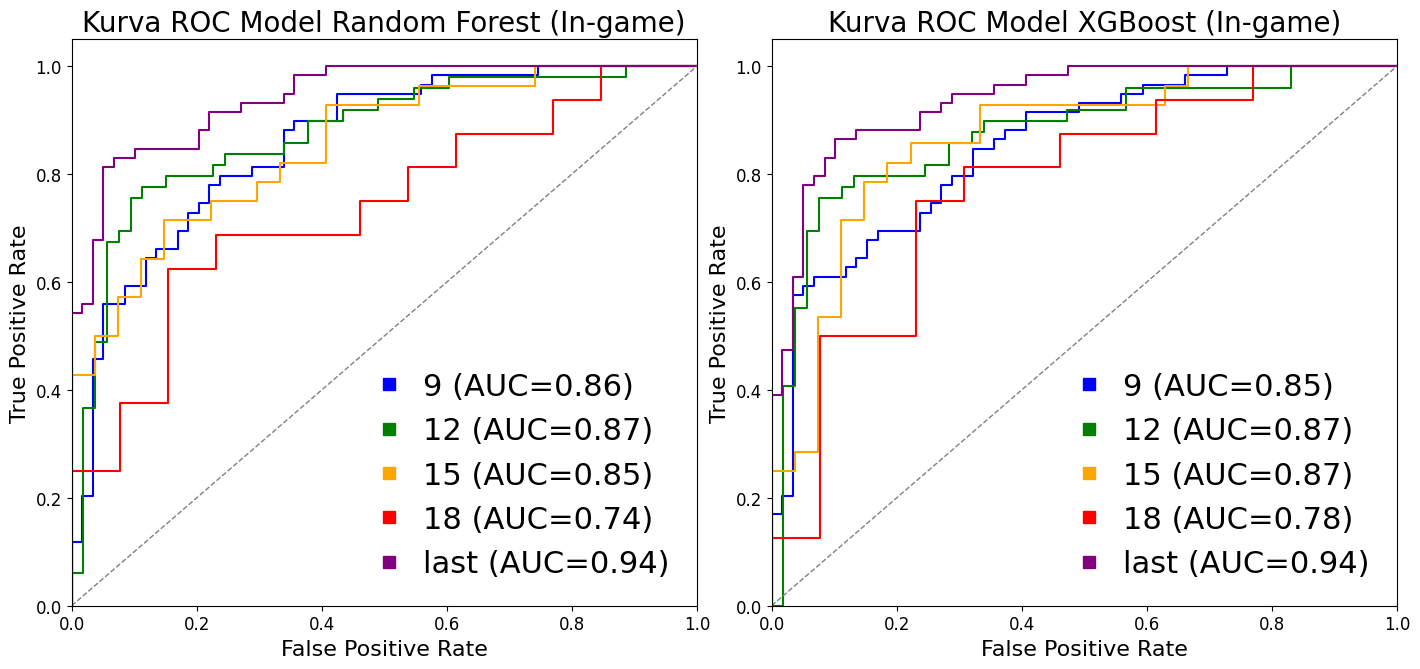

In [92]:
def plot_ingame_roc_curves(figsize, line_width, diagonal_width, marker_size,
                            label_fontsize, title_fontsize, tick_fontsize, legend_fontsize, title_pad):
    """Render ROC curves for RF and XGBoost, one subplot each, with one line
    per snapshot stage (9/12/15/18/last). Reused for both the full-size and
    compact (report-ready) versions."""
    snapshots = ['9','12','15','18','last']
    test_sets = {
        '9': features_df_test[features_df_test["snapshot_stage"]==9],
        '12': features_df_test[features_df_test["snapshot_stage"]==12],
        '15': features_df_test[features_df_test["snapshot_stage"]==15],
        '18': features_df_test[features_df_test["snapshot_stage"]==18],
        'last': features_df_test_last
    }

    colors = ['blue', 'green', 'orange', 'red', 'purple']
    models = {'Random Forest': rf, 'XGBoost': xgb}

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, (model_name, model) in zip(axes, models.items()):
        for i, snap in enumerate(snapshots):
            df_stage = test_sets[snap]
            X_test = df_stage[diff_cols].copy()
            y_test = df_stage["winner"]

            probs = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)

            ax.plot(fpr, tpr, color=colors[i], lw=line_width)
            # Dummy plot just to render a square marker in the legend per snapshot
            ax.plot([], [], color=colors[i], marker='s', linestyle='None',
                    markersize=marker_size, label=f'{snap} (AUC={roc_auc:.2f})')

        ax.plot([0,1], [0,1], color='gray', lw=diagonal_width, linestyle='--')
        ax.set_xlim([0,1])
        ax.set_ylim([0,1.05])
        ax.set_xlabel('FPR' if figsize[0] < 10 else 'False Positive Rate', fontsize=label_fontsize)
        ax.set_ylabel('TPR' if figsize[0] < 10 else 'True Positive Rate', fontsize=label_fontsize)
        ax.set_title(f'ROC {model_name}' if figsize[0] < 10 else f'Kurva ROC Model {model_name} (In-game)',
                     fontsize=title_fontsize, pad=title_pad)
        ax.tick_params(labelsize=tick_fontsize)
        ax.legend(
            loc="lower right",
            prop={'size': legend_fontsize},
            frameon=False,
            handletextpad=0.1
        )

    plt.tight_layout(pad=0.5 if figsize[0] < 10 else 0)
    plt.show()


# Version 1: full-size, for on-screen inspection
plot_ingame_roc_curves(
    figsize=(14, 6.5), line_width=1.5, diagonal_width=1, marker_size=8,
    label_fontsize=16, title_fontsize=20, tick_fontsize=12, legend_fontsize=22, title_pad=6
)

# # Version 2: compact, for report/paper embedding
# plot_ingame_roc_curves(
#     figsize=(7.2, 3.2), line_width=1, diagonal_width=0.8, marker_size=5,
#     label_fontsize=8, title_fontsize=9, tick_fontsize=7, legend_fontsize=10, title_pad=3
# )

### Confusion Matrix for Last Snapshot

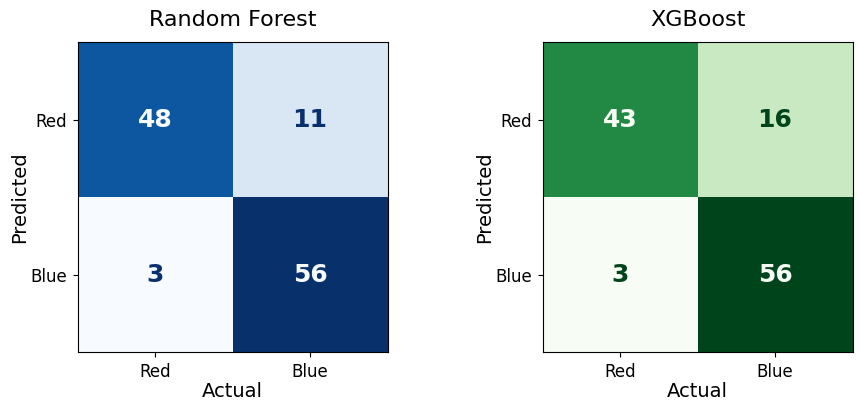

In [93]:
# ===== 4. IN-GAME CONFUSION MATRIX =====
cm_rf = confusion_matrix(y_test_last, rf_pred, labels=[1, 0])
cm_xgb = confusion_matrix(y_test_last, xgb_pred, labels=[1, 0])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["Red", "Blue"])
disp_xgb = ConfusionMatrixDisplay(cm_xgb, display_labels=["Red", "Blue"])

disp_rf.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
disp_xgb.plot(ax=axes[1], cmap="Greens", colorbar=False, values_format="d")

for ax, title in zip(axes, ["Random Forest", "XGBoost"]):
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel("Actual", fontsize=14, labelpad=1)
    ax.set_ylabel("Predicted", fontsize=14, labelpad=1)
    ax.tick_params(labelsize=12, pad=4)
    for label in ax.texts: label.set_fontsize(18); label.set_fontweight("bold")

plt.subplots_adjust(wspace=0.5, hspace=0)
plt.show()

### Feature Importance

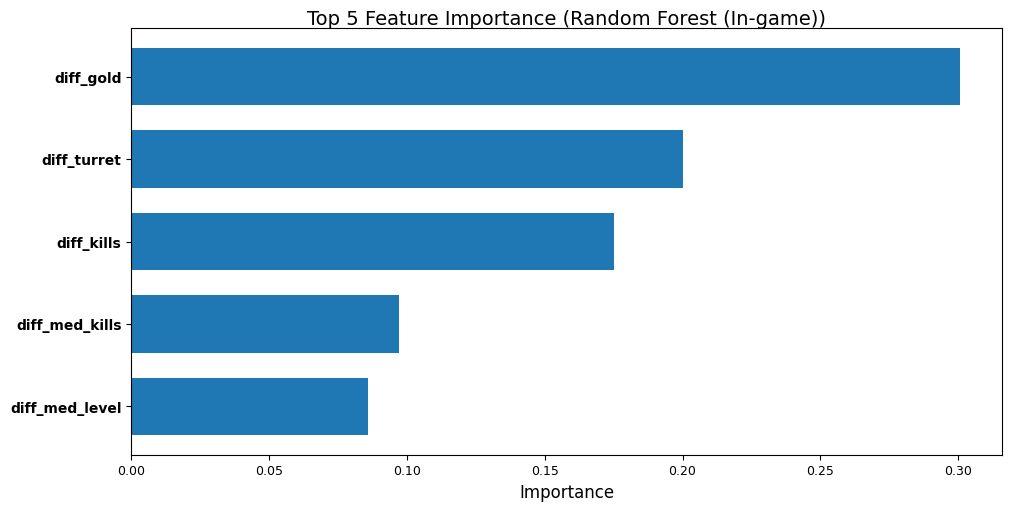

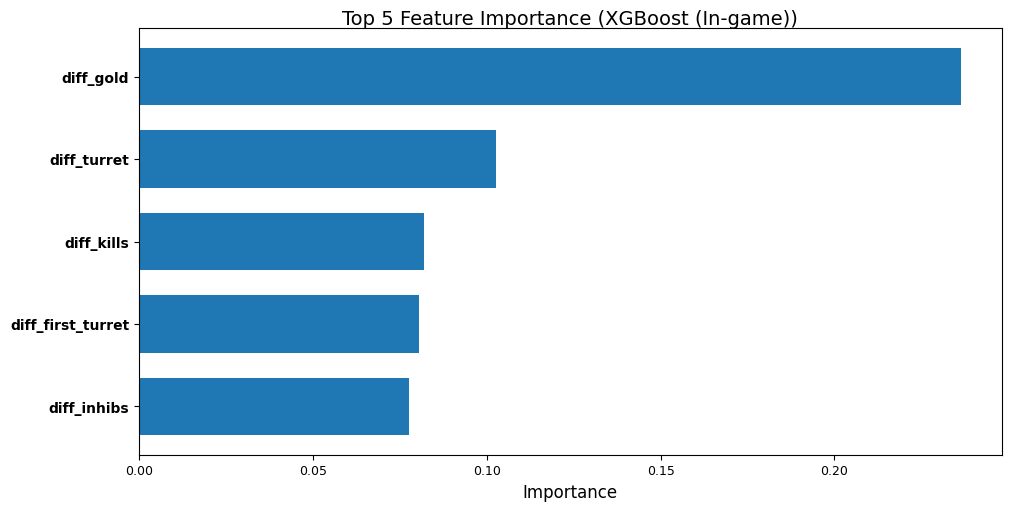

In [94]:
def plot_ingame_feature_importance(model, name, figsize, bar_height,
                                    title_fontsize, xlabel_fontsize, tick_fontsize):
    """Render top-5 feature importance for a single in-game model.
    Reused for both the full-size and compact (report-ready) versions."""
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False).head(5)

    plt.figure(figsize=figsize)
    plt.barh(importance['feature'][::-1], importance['importance'][::-1], height=bar_height)
    plt.yticks(fontsize=tick_fontsize, fontweight='bold')
    plt.xlabel('Importance', fontsize=xlabel_fontsize)
    plt.title(f'Top 5 Feature Importance ({name})', fontsize=title_fontsize, pad=2)
    plt.xticks(fontsize=tick_fontsize - 1 if tick_fontsize > 6 else tick_fontsize)
    plt.tight_layout(pad=0.3)
    plt.show()


models = {
    'Random Forest (In-game)': rf,
    'XGBoost (In-game)': xgb
}

for name, model in models.items():
    # Version 1: full-size chart for on-screen inspection
    plot_ingame_feature_importance(
        model, name, figsize=(10, 5), bar_height=0.7,
        title_fontsize=14, xlabel_fontsize=12, tick_fontsize=10
    )

    # # Version 2: compact 4x2-inch chart for report/paper embedding
    # plot_ingame_feature_importance(
    #     model, name, figsize=(4, 2.0), bar_height=0.55,
    #     title_fontsize=8, xlabel_fontsize=7, tick_fontsize=8
    # )

### Example Win Probability per Snapshot

#### Setup & Demo Selection

In [95]:
from IPython.display import display

import plotly.graph_objects as go
from plotly.subplots import make_subplots

X_test  = features_df_test[diff_cols].copy()
y_test  = features_df_test["winner"]

# Slice the demo window: 4 consecutive snapshots (9/12/15/18 min) belonging
# to the same match. features_df_test / msc25_df_snapshots share the same
# row order and length (build_features() processes rows 1:1, no filtering),
# so the same positional slice on msc25_df_snapshots gives the matching
# raw match info for these rows.
DEMO_START, DEMO_END = 285, 289

X_demo = X_test.iloc[DEMO_START:DEMO_END]
y_demo = y_test.iloc[DEMO_START:DEMO_END]
raw_demo = msc25_df_snapshots.iloc[DEMO_START:DEMO_END]

snapshots = X_demo["snapshot_stage"].tolist()
blue_probs = rf.predict_proba(X_demo)[:, 0] * 100
red_probs  = rf.predict_proba(X_demo)[:, 1] * 100

roles = ["explaner", "jungler", "midlaner", "goldlaner", "roamer"]

def parse_kda_field(s):
    """Safely parse a 'k_d_a' string (e.g. '5_2_10') into (kills, deaths, assists).
    Returns (0, 0, 0) for NaN, malformed strings, or parsing errors.
    Local duplicate of the same helper defined inside build_features() (cell 116),
    kept separate here since that version is scoped inside build_features and
    not importable directly."""
    try:
        if pd.isna(s):
            return (0, 0, 0)
        parts = s.split("_")
        return tuple(int(p) if p.isdigit() or (p and p[0] == "-" and p[1:].isdigit()) else 0 for p in (parts + ["0", "0", "0"])[:3])
    except Exception:
        return (0, 0, 0)

# After (tambahkan di cell "#### Setup & Demo Selection", setelah parse_kda_field)
def display_left(df):
    """Display a DataFrame with all cell text left-aligned (pandas default is
    right-aligned), for better readability on these mostly-text tables."""
    display(df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
        [{'selector': 'th', 'props': [('text-align', 'left')]}]  # header cells too
    ))

#### Match Info

In [96]:
# Pull match identity from the first row (same match across all 4 snapshot rows)
match_info = raw_demo.iloc[0]
actual_winner = match_info["winner_team"]
actual_winner_side = match_info["winner"]

match_info_df = pd.DataFrame([
    ("Match ID", match_info["match_id"]),
    ("Game ID", match_info["game_id"]),
    ("Best Of", match_info["best_of"]),
    ("Game Number", match_info["game_number"]),
    ("Tournament", f"{match_info['tournament']} ({match_info['stage']})"),
    ("Teams", f"{match_info['blue_team']} (Blue) vs {match_info['red_team']} (Red)"),
    ("Patch", match_info["patch_version"]),
    ("Date (WIB)", match_info["date_wib"]),
    ("Game Duration", match_info["game_duration"]),
    ("Actual Winner", f"{actual_winner} ({actual_winner_side})"),
], columns=["Field", "Value"])

display_left(match_info_df)

,Field,Value
0,Match ID,MSC2025PLO_RxMTP
1,Game ID,MSC2025PLO_RxMTP-4
2,Best Of,5
3,Game Number,4
4,Tournament,MSC 2025 (Knockout Stage)
5,Teams,ONIC Philippines (Blue) vs ONIC (Red)
6,Patch,Patch 1.9.91.1
7,Date (WIB),02/08/2025 15.00
8,Game Duration,00.21.47
9,Actual Winner,ONIC Philippines (blue)


#### Draft Pick

In [97]:
draft_rows = [
    (r.capitalize(), match_info[f"blue_{r}"], match_info[f"red_{r}"])
    for r in roles
]
draft_rows.append(("Bans", match_info["blue_bans"], match_info["red_bans"]))

draft_df = pd.DataFrame(draft_rows, columns=["Role", "Blue", "Red"])
display_left(draft_df)

,Role,Blue,Red
0,Explaner,Gloo,Baxia
1,Jungler,Yi Sun-shin,Lancelot
2,Midlaner,Pharsa,Kadita
3,Goldlaner,Granger,Claude
4,Roamer,Badang,Chou
5,Bans,"Kalea,Zhuxin,Gatotkaca,Lapu-Lapu,Arlott","Selena,Wanwan,Cici,Ruby,Phoveus"


#### Match State per Snapshot

In [98]:
# One table per snapshot stage. Rows: total_gold, per-role level+KDA, and
# objective counts (turret/inhibitor/turtle/lord). Each table is preceded by
# a short header line noting the snapshot minute and the model's predicted side.
for i, (snap, bp, rp) in enumerate(zip(snapshots, blue_probs, red_probs)):
    snap_row = raw_demo.iloc[i]
    predicted_side = "Blue" if bp > rp else "Red"

    print(f"Snapshot: {snap} min  |  Win Probability -> Blue: {bp:.1f}%  |  Red: {rp:.1f}%  |  Predicted: {predicted_side}")

    state_rows = [("Total Gold", snap_row["blue_total_gold"], snap_row["red_total_gold"])]

    for r in roles:
        blue_k, blue_d, blue_a = parse_kda_field(snap_row[f"blue_{r}_kda"])
        red_k, red_d, red_a    = parse_kda_field(snap_row[f"red_{r}_kda"])

        state_rows.append((
            f"{r.capitalize()} Lvl / KDA",
            f"{snap_row[f'blue_{r}_level']}\t| {blue_k} / {blue_d} / {blue_a}",
            f"{snap_row[f'red_{r}_level']}\t| {red_k} / {red_d} / {red_a}"
        ))

    state_rows += [
        ("Total Turret", snap_row["blue_total_turret"], snap_row["red_total_turret"]),
        ("Total Inhibitor", snap_row["blue_total_inhibitor"], snap_row["red_total_inhibitor"]),
        ("Total Turtle", snap_row["blue_total_turtle"], snap_row["red_total_turtle"]),
        ("Total Lord", snap_row["blue_total_lord"], snap_row["red_total_lord"]),
    ]

    state_df = pd.DataFrame(state_rows, columns=["Stat", "Blue", "Red"])
    display_left(state_df)
    print("-"* 70)

Snapshot: 9 min  |  Win Probability -> Blue: 80.8%  |  Red: 19.2%  |  Predicted: Blue


,Stat,Blue,Red
0,Total Gold,26600,21900
1,Explaner Lvl / KDA,9 | 0 / 2 / 4,8 | 1 / 2 / 1
2,Jungler Lvl / KDA,13 | 1 / 0 / 4,12 | 0 / 0 / 2
3,Midlaner Lvl / KDA,9 | 0 / 0 / 3,9 | 0 / 1 / 1
4,Goldlaner Lvl / KDA,11 | 4 / 0 / 0,10 | 1 / 0 / 0
5,Roamer Lvl / KDA,9 | 0 / 0 / 3,8 | 0 / 2 / 0
6,Total Turret,3,1
7,Total Inhibitor,0,0
8,Total Turtle,3,0
9,Total Lord,0,0


----------------------------------------------------------------------
Snapshot: 12 min  |  Win Probability -> Blue: 57.5%  |  Red: 42.5%  |  Predicted: Blue


,Stat,Blue,Red
0,Total Gold,34200,32700
1,Explaner Lvl / KDA,11 | 0 / 3 / 5,10 | 1 / 2 / 2
2,Jungler Lvl / KDA,15 | 1 / 1 / 5,15 | 2 / 0 / 3
3,Midlaner Lvl / KDA,11 | 0 / 0 / 5,11 | 1 / 2 / 3
4,Goldlaner Lvl / KDA,14 | 6 / 0 / 0,13 | 1 / 0 / 3
5,Roamer Lvl / KDA,10 | 0 / 1 / 6,10 | 0 / 3 / 2
6,Total Turret,4,2
7,Total Inhibitor,0,0
8,Total Turtle,3,0
9,Total Lord,0,1


----------------------------------------------------------------------
Snapshot: 15 min  |  Win Probability -> Blue: 37.9%  |  Red: 62.1%  |  Predicted: Red


,Stat,Blue,Red
0,Total Gold,41900,43000
1,Explaner Lvl / KDA,12 | 0 / 4 / 6,12 | 1 / 3 / 5
2,Jungler Lvl / KDA,15 | 1 / 1 / 6,15 | 5 / 0 / 3
3,Midlaner Lvl / KDA,13 | 0 / 0 / 6,13 | 1 / 2 / 6
4,Goldlaner Lvl / KDA,15 | 7 / 1 / 0,15 | 1 / 0 / 6
5,Roamer Lvl / KDA,12 | 0 / 2 / 7,12 | 0 / 3 / 4
6,Total Turret,4,5
7,Total Inhibitor,0,0
8,Total Turtle,3,0
9,Total Lord,0,2


----------------------------------------------------------------------
Snapshot: 18 min  |  Win Probability -> Blue: 33.6%  |  Red: 66.4%  |  Predicted: Red


,Stat,Blue,Red
0,Total Gold,49600,52100
1,Explaner Lvl / KDA,14 | 0 / 4 / 6,14 | 1 / 3 / 5
2,Jungler Lvl / KDA,15 | 1 / 1 / 6,15 | 5 / 0 / 3
3,Midlaner Lvl / KDA,15 | 0 / 0 / 6,15 | 1 / 2 / 6
4,Goldlaner Lvl / KDA,15 | 7 / 1 / 0,15 | 1 / 0 / 6
5,Roamer Lvl / KDA,13 | 0 / 2 / 7,13 | 0 / 3 / 4
6,Total Turret,4,6
7,Total Inhibitor,0,1
8,Total Turtle,3,0
9,Total Lord,0,2


----------------------------------------------------------------------


#### Win Probability Chart — Interactive

In [99]:
# Interactive Plotly chart (requires JS rendering — works in Jupyter/Colab,
# but will NOT render in static exports like PDF, GitHub preview, or nbviewer)
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.02,
                    row_heights=[0.6, 0.4])

# Blue area (top)
fig.add_trace(
    go.Scatter(
        x=snapshots,
        y=blue_probs,
        name="Blue Side",
        fill='tozeroy',
        fillcolor='rgba(3,161,251,0.5)',
        line=dict(color='rgb(3,161,251)'),
        mode='lines+markers',
        hovertemplate='%{x} min<br>Blue: %{y:.1f}%<extra></extra>'
    ),
    row=1, col=1
)

# Red area (bottom)
fig.add_trace(
    go.Scatter(
        x=snapshots,
        y=red_probs,
        name="Red Side",
        fill='tozeroy',
        fillcolor='rgba(250,82,82,0.5)',
        line=dict(color='rgb(250,82,82)'),
        mode='lines+markers',
        hovertemplate='%{x} min<br>Red: %{y:.1f}%<extra></extra>'
    ),
    row=2, col=1
)

fig.update_yaxes(title_text='Win Probability [%]', range=[50, 100], row=1, col=1)
fig.update_yaxes(range=[100, 50], autorange=False, row=2, col=1)  # terbalik
fig.update_xaxes(title_text='Match Time [min]', row=2, col=1)
fig.update_layout(
    title=f"Win Probability per Snapshot — {match_info['blue_team']} (Blue) vs {match_info['red_team']} (Red) | ({match_info['tournament']})",
    height=460, width=900,
    showlegend=True
)

fig.show()

#### Win Probability Chart — Static Fallback

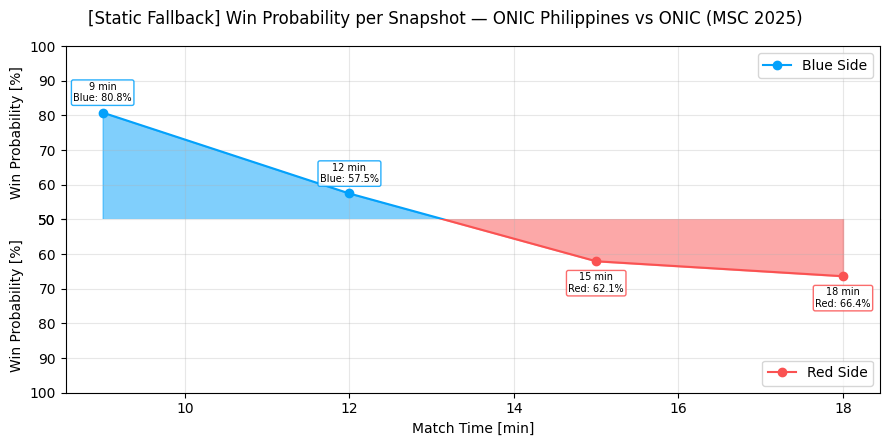

In [100]:
# --- Static fallback (matplotlib) ---
# Renders as a plain raster image, guaranteed to display in any environment
# (PDF export, GitHub preview, nbviewer) even where the interactive Plotly
# chart above won't render. Since a static image can't support hover
# tooltips, each point's value is instead shown as a permanent label
# (equivalent info to the Plotly hover tooltip, always visible).
fig_static, axes_static = plt.subplots(
    2, 1, figsize=(9, 4.5), sharex=True,
    gridspec_kw={'hspace': 0}
)

axes_static[0].fill_between(snapshots, blue_probs, color='#03A1FB', alpha=0.5)
axes_static[0].plot(snapshots, blue_probs, color='#03A1FB', marker='o', label='Blue Side')
axes_static[0].set_ylim(50, 100)
axes_static[0].set_ylabel('Win Probability [%]')
axes_static[0].legend(loc='upper right')
axes_static[0].grid(alpha=0.3)
axes_static[0].spines['bottom'].set_visible(False)
axes_static[0].tick_params(axis='x', which='both', bottom=False)

# Label each Blue dot with "<snap> min, Blue: <value>%", offset slightly above the point
for snap, val in zip(snapshots, blue_probs):
    axes_static[0].annotate(
        f"{snap} min\nBlue: {val:.1f}%",
        xy=(snap, val),
        xytext=(0, 8), textcoords='offset points',
        ha='center', fontsize=7,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#03A1FB', alpha=0.85)
    )

axes_static[1].fill_between(snapshots, red_probs, color='#FA5252', alpha=0.5)
axes_static[1].plot(snapshots, red_probs, color='#FA5252', marker='o', label='Red Side')
axes_static[1].set_ylim(100, 50)
axes_static[1].set_xlabel('Match Time [min]')
axes_static[1].set_ylabel('Win Probability [%]')
axes_static[1].legend(loc='lower right')
axes_static[1].grid(alpha=0.3)
axes_static[1].spines['top'].set_visible(False)

# Label each Red dot the same way, offset slightly below the point
# (panel is y-inverted, so "below the point" visually means positive offset here too)
for snap, val in zip(snapshots, red_probs):
    axes_static[1].annotate(
        f"{snap} min\nRed: {val:.1f}%",
        xy=(snap, val),
        xytext=(0, -8), textcoords='offset points',
        ha='center', va='top', fontsize=7,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#FA5252', alpha=0.85)
    )

fig_static.suptitle(
    f"[Static Fallback] Win Probability per Snapshot — "
    f"{match_info['blue_team']} vs {match_info['red_team']} ({match_info['tournament']})"
)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()